# H1 클러스터링 실험: 파킹 유저 분리

**목표:** K-Means + DBSCAN으로 파킹 유저 클러스터 분리 가능성 검증 (H1)

**피처 세트 (Feature Set A — raw):**  
`avg_monthly_delta_level`, `delta_cp_winsor` (winsorized P5–P95), `avg_monthly_delta_union_level` (clamped ≥ 0), `avg_monthly_delta_authentic_symbol`, `avg_monthly_delta_arcane_symbol` (clamped ≥ 0)

> `arcane_stagnant` binary 제거 — binary 피처가 K-Means에서 단일 축으로 클러스터를 지배하는 문제 해결.  
> `arcane_stagnant`는 `stagnation_score` 계산 및 사후 검증에만 사용.

**데이터:** `data/features_monthly.csv` → level 270–290 필터 후 ~2,000명  
(EDA Sec 10 preprocess() 동일 전처리 재현 — eda.ipynb 수정 없음)

In [1]:
import os
os.makedirs("figures", exist_ok=True)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager
_font_path = "../assets/NanumSquareNeo-bRg.ttf"
font_manager.fontManager.addfont(_font_path)
_font_prop = font_manager.FontProperties(fname=_font_path)
matplotlib.rcParams["font.family"] = _font_prop.get_name()
matplotlib.rcParams["axes.unicode_minus"] = False
import seaborn as sns
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# ── EDA Sec 10 preprocess() 재현 ─────────────────────────────────────────────
df_raw = pd.read_csv("../data/features_monthly.csv", encoding="utf-8-sig")
mc     = pd.read_csv("../data/main_characters.csv", encoding="utf-8-sig",
                     usecols=["ocid", "class_group"])
df     = df_raw.merge(mc, on="ocid", how="left")

df = df[df["level"].between(270, 290)].copy()
df["level_bin"] = pd.cut(df["level"], bins=[269, 279, 285, 290],
                          labels=["270-279", "280-285", "286-290"])

_core = ["avg_monthly_delta_level", "avg_monthly_delta_combat_power",
         "avg_monthly_delta_union_level"]
df = df.dropna(subset=_core).copy()

for c in ["avg_monthly_delta_arcane_symbol", "avg_monthly_delta_authentic_symbol"]:
    df.loc[df[c] < 0, c] = 0
df["union_level"] = df["union_level"].fillna(0)
df["delta_cp_winsor"] = np.array(
    winsorize(df["avg_monthly_delta_combat_power"].values, limits=[0.05, 0.05])
)
# arcane_stagnant: stagnation_score 계산 및 사후 검증 전용 (클러스터링 피처 아님)
df["arcane_stagnant"] = (
    (df["arcane_symbol_score"] < 120) & (df["avg_monthly_delta_arcane_symbol"] == 0)
).astype(int)

df_final = df.reset_index(drop=True)

# ── 레벨 구간 팔레트 (EDA와 동일) ────────────────────────────────────────────
BAND_LABELS  = ["270-279", "280-285", "286-290"]
BAND_PALETTE = {"270-279": "#4e79a7", "280-285": "#f28e2b", "286-290": "#e15759"}

# ── stagnation_score ──────────────────────────────────────────────────────────
_stag_features = ["avg_monthly_delta_level", "delta_cp_winsor",
                  "avg_monthly_delta_union_level", "avg_monthly_delta_authentic_symbol"]
df_final["stagnation_score"] = (
    sum((df_final[c] <= df_final[c].quantile(0.25)).astype(int)
        for c in _stag_features)
    + df_final["arcane_stagnant"]
)

# ── Feature Set A (12mo avg — 확정) ──────────────────────────────────────────
# arcane_stagnant binary 제거: K-Means에서 binary 피처가 단일 축으로 클러스터를 지배하는
# 문제 방지. avg_monthly_delta_arcane_symbol (연속형, ≥0 클램핑)으로 대체.
CLUSTER_FEATURES = [
    "avg_monthly_delta_level",
    "delta_cp_winsor",
    "avg_monthly_delta_union_level",
    "avg_monthly_delta_authentic_symbol",
    "avg_monthly_delta_arcane_symbol",
]
X_raw  = df_final[CLUSTER_FEATURES].dropna()
idx    = X_raw.index
scaler = StandardScaler()
X      = scaler.fit_transform(X_raw)

# ── Feature Set A' (recent6 — age-debiased for 신규클래스/렌) ────────────────
RECENT6_COLS = ["recent6_delta_level", "recent6_delta_combat_power",
                "recent6_delta_union_level", "recent6_delta_authentic_symbol"]
has_recent6 = all(c in df_final.columns for c in RECENT6_COLS)

if has_recent6:
    df_final["r6_delta_cp"] = np.array(
        winsorize(
            df_final["recent6_delta_combat_power"].fillna(df_final["delta_cp_winsor"]),
            limits=[0.05, 0.05]
        )
    )
    df_final["r6_delta_union"] = (
        df_final["recent6_delta_union_level"]
        .fillna(df_final["avg_monthly_delta_union_level"])
        .clip(lower=0)
    )
    _arcane_r6_col = "recent6_delta_arcane_symbol" if "recent6_delta_arcane_symbol" in df_final.columns \
                     else "avg_monthly_delta_arcane_symbol"
    df_final["r6_delta_arcane"] = (
        df_final[_arcane_r6_col]
        .fillna(df_final["avg_monthly_delta_arcane_symbol"])
        .clip(lower=0)
    )
    CLUSTER_FEATURES_Ap = [
        "recent6_delta_level",
        "r6_delta_cp",
        "r6_delta_union",
        "recent6_delta_authentic_symbol",
        "r6_delta_arcane",
    ]
    df_Ap  = df_final[CLUSTER_FEATURES_Ap].dropna()
    idx_Ap = df_Ap.index
    X_Ap   = StandardScaler().fit_transform(df_Ap.values)
else:
    CLUSTER_FEATURES_Ap = None
    idx_Ap = None
    X_Ap   = None

has_ciw = "created_in_window" in df_final.columns

print(f"df_final                          : {len(df_final):,}명")
print(f"Feature Set A  (12mo avg)  샘플   : {len(X):,}명")
if has_recent6:
    _arcane_src = "recent6_delta_arcane_symbol" if "recent6_delta_arcane_symbol" in df_final.columns else "avg_monthly_delta_arcane_symbol (fallback)"
    print(f"Feature Set A' (recent6)   샘플   : {len(X_Ap):,}명  (arcane: {_arcane_src})")
else:
    print("Feature Set A'                    : recent6_delta_* 없음 (collect_features v2.2+ 필요)")
if has_ciw:
    n_new = int(df_final.loc[idx, "created_in_window"].fillna(0).eq(1).sum())
    print(f"created_in_window=1 (신규클래스/렌) : {n_new}명 ({100*n_new/len(X):.1f}%)")
print(f"stagnation=5                      : {(df_final['stagnation_score'] == 5).sum()}명")
print(f"parked_proxy (delta_level≤0.1)    : {(df_final['avg_monthly_delta_level'] <= 0.1).mean():.1%}")

df_final                          : 1,337명
Feature Set A  (12mo avg)  샘플   : 1,337명
Feature Set A' (recent6)   샘플   : 1,337명  (arcane: recent6_delta_arcane_symbol)
created_in_window=1 (신규클래스/렌) : 194명 (14.5%)
stagnation=5                      : 7명
parked_proxy (delta_level≤0.1)    : 58.6%


## 피처 선택: 피처별 Silhouette 진단

클러스터링에 쓸 피처를 고르기 위해 **각 후보 피처의 단독 silhouette**과 **leave-one-out 기여도**를 측정.

- **단독 silhouette**: 피처 1개만 StandardScale → KMeans(k=2~8) → 최고 silhouette. 높을수록 그 피처 단독으로 클러스터 구조가 뚜렷.
- **leave-one-out**: 전체 A셋(5피처)에서 피처 1개 제거 후 silhouette. `Δ<0` = 제거 시 악화 = 유지해야 할 피처.


In [ ]:
# ── 피처 선택용 silhouette 진단 ───────────────────────────────────────────────
# (1) 단독 피처별 silhouette  (2) 전체 A셋 leave-one-out 기여도
ks_fs = list(range(2, 9))

CANDIDATE_FEATURES = [
    "avg_monthly_delta_level",
    "delta_cp_winsor",
    "avg_monthly_delta_union_level",
    "avg_monthly_delta_authentic_symbol",
    "avg_monthly_delta_arcane_symbol",
]
if "avg_monthly_delta_hexa" in df_final.columns:
    CANDIDATE_FEATURES.append("avg_monthly_delta_hexa")

def best_silhouette(mat):
    """k=2~8 중 최고 silhouette와 해당 k 반환."""
    sils = [silhouette_score(mat,
                KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(mat))
            for k in ks_fs]
    return max(sils), ks_fs[int(np.argmax(sils))]

# (1) 단독 피처 silhouette ----------------------------------------------------
rows = []
for feat in CANDIDATE_FEATURES:
    col = df_final[feat].dropna()
    Xf  = StandardScaler().fit_transform(col.values.reshape(-1, 1))
    sil, bk = best_silhouette(Xf)
    rows.append({"feature": feat, "best_k": bk, "silhouette": sil, "n": len(col)})
feat_sil = (pd.DataFrame(rows)
            .sort_values("silhouette", ascending=False)
            .reset_index(drop=True))
print("── 단독 피처별 silhouette (내림차순) ──")
display(feat_sil.round(4))

# (2) 전체 A셋 leave-one-out --------------------------------------------------
base_sil, base_k = best_silhouette(X)
loo = []
for feat in CLUSTER_FEATURES:
    keep = [c for c in CLUSTER_FEATURES if c != feat]
    Xk   = StandardScaler().fit_transform(df_final.loc[idx, keep].values)
    s, _ = best_silhouette(Xk)
    loo.append({"dropped": feat, "silhouette_wo": s, "delta_vs_full": s - base_sil})
loo_df = (pd.DataFrame(loo)
          .sort_values("delta_vs_full")
          .reset_index(drop=True))
print(f"\n전체 A셋(5피처) best silhouette = {base_sil:.4f}  (k={base_k})")
print("── leave-one-out: 피처 제거 시 silhouette (Δ<0 = 유지해야 할 피처) ──")
display(loo_df.round(4))

# ── 막대그래프 ────────────────────────────────────────────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 4.5))

fs_r = feat_sil.iloc[::-1]
axL.barh(fs_r["feature"], fs_r["silhouette"], color="steelblue")
axL.set_xlabel("best silhouette (단독 피처)")
axL.set_title("피처별 단독 silhouette")
for i, v in enumerate(fs_r["silhouette"]):
    axL.text(v, i, f" {v:.3f}", va="center", fontsize=9)

loo_r  = loo_df.iloc[::-1]
colors = ["crimson" if d < 0 else "gray" for d in loo_r["delta_vs_full"]]
axR.barh(loo_r["dropped"], loo_r["delta_vs_full"], color=colors)
axR.axvline(0, color="black", linewidth=0.8)
axR.set_xlabel("Δ silhouette vs 전체 A셋")
axR.set_title("leave-one-out 기여도 (Δ<0 = 중요)")

plt.suptitle("Feature Set A — 피처 선택용 silhouette 진단", y=1.02)
plt.tight_layout()
plt.savefig("figures/00_feature_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


Best k = 4,  Silhouette = 0.5849
  k=2: 0.5585
  k=3: 0.5784
  k=4: 0.5849 <-- best
  k=5: 0.5071
  k=6: 0.4955
  k=7: 0.5026
  k=8: 0.4995


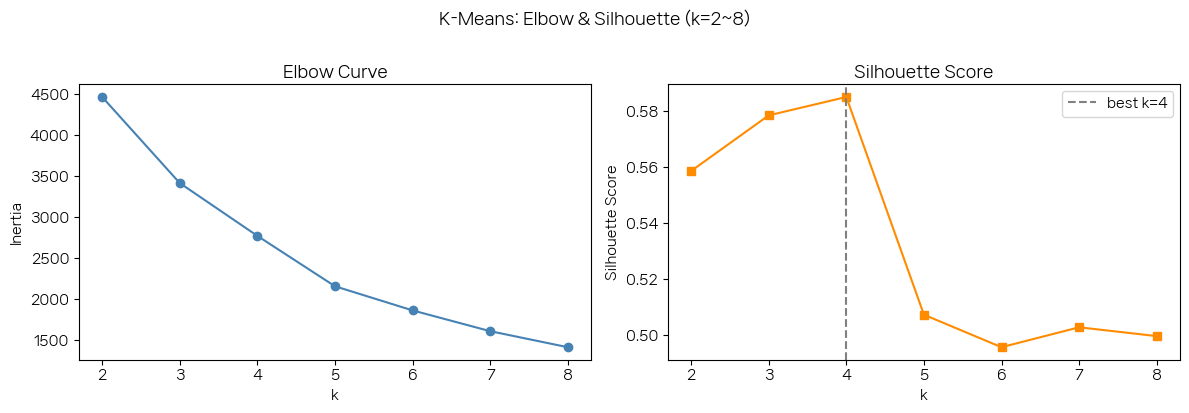

In [2]:
ks          = list(range(2, 9))
inertias    = []
silhouettes = []

for k in ks:
    km     = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels))

best_k   = ks[int(np.argmax(silhouettes))]
best_sil = max(silhouettes)
print(f'Best k = {best_k},  Silhouette = {best_sil:.4f}')
for k, sil in zip(ks, silhouettes):
    marker = ' <-- best' if k == best_k else ''
    print(f'  k={k}: {sil:.4f}{marker}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, inertias, 'o-', color='steelblue')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Curve'); ax1.set_xticks(ks)

ax2.plot(ks, silhouettes, 's-', color='darkorange')
ax2.axvline(best_k, linestyle='--', color='gray', label=f'best k={best_k}')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score'); ax2.set_xticks(ks); ax2.legend()

plt.suptitle('K-Means: Elbow & Silhouette (k=2~8)', y=1.02)
plt.tight_layout()
plt.savefig("figures/01_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


## Feature Set A' (recent6 — 렌 코호트 age bias 제거)

Feature Set A의 `avg_monthly_delta_*` (12개월 전체 평균) 대신 `recent6_delta_*` (최근 6개월 기울기) 사용.

**목적:** 2025-06 출시 신직업(렌)은 초기 급격한 레벨업으로 12mo delta가 인위적으로 높아,  
파킹 중이어도 '활성'으로 오분류될 수 있음. recent6은 연령(age) 편향 없는 '현재 파킹' 신호를 반영.


── Feature Set A vs A' Silhouette 비교 ──────────────────────────────
   A  (12mo avg)  A' (recent6) 
k                              
2         0.5585         0.8106
3         0.5784         0.6427
4         0.5849         0.6560
5         0.5071         0.6463
6         0.4955         0.6450
7         0.5026         0.6469
8         0.4995         0.6552

A  best: k=4,    sil=0.5849
A' best: k=2, sil=0.8106


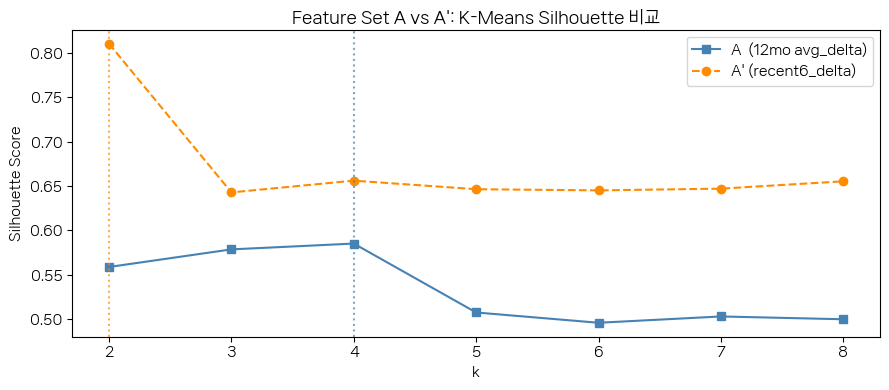


Feature Set A' 파킹 클러스터 ID = 0


,recent6_delta_level,r6_delta_cp,r6_delta_union,recent6_delta_authentic_symbol,r6_delta_arcane,arcane_stagnant,stagnation_score,n,is_parking,parked_proxy_%
cluster_km_Ap,,,,,,,,,,
0.0,0.2006,5.664288e+04,14.4752,0.2070,0.0394,0.1588,1.6911,1285,1,70.7393
1.0,4.0093,2.012061e+06,139.7391,3.7231,13.9538,0.0192,0.7500,52,0,34.6154


In [3]:
if X_Ap is None:
    print("Feature Set A' 불가 — recent6_delta_* 컬럼 없음")
    print("collect_features.py v2.2 이상으로 수집된 데이터 필요")
else:
    ks_Ap   = list(range(2, 9))
    sils_Ap = []
    for k in ks_Ap:
        lbl_Ap = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_Ap)
        sils_Ap.append(silhouette_score(X_Ap, lbl_Ap))

    best_k_Ap   = ks_Ap[int(np.argmax(sils_Ap))]
    best_sil_Ap = max(sils_Ap)

    # ── Silhouette 비교표 ──────────────────────────────────────────────────────
    comp = pd.DataFrame({
        'k': ks,
        'A  (12mo avg)': silhouettes,
        "A' (recent6) ": sils_Ap,
    }).set_index('k').round(4)
    print("── Feature Set A vs A' Silhouette 비교 ──────────────────────────────")
    print(comp.to_string())
    print(f"\nA  best: k={best_k},    sil={best_sil:.4f}")
    print(f"A' best: k={best_k_Ap}, sil={best_sil_Ap:.4f}")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(ks,    silhouettes, 's-',  color='steelblue',  label='A  (12mo avg_delta)')
    ax.plot(ks_Ap, sils_Ap,    'o--', color='darkorange', label="A' (recent6_delta)")
    ax.axvline(best_k,    linestyle=':', color='steelblue',  alpha=0.7)
    ax.axvline(best_k_Ap, linestyle=':', color='darkorange', alpha=0.7)
    ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
    ax.set_title("Feature Set A vs A': K-Means Silhouette 비교")
    ax.set_xticks(ks); ax.legend()
    plt.tight_layout()
    plt.savefig("figures/04_silhouette_compare_A_Ap.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── A' 최적 K-Means 피팅 ──────────────────────────────────────────────────
    km_Ap_best = KMeans(n_clusters=best_k_Ap, n_init=20, random_state=42)
    df_final.loc[idx_Ap, 'cluster_km_Ap'] = km_Ap_best.fit_predict(X_Ap)

    profile_Ap = df_final.loc[idx_Ap].groupby('cluster_km_Ap')[
        CLUSTER_FEATURES_Ap + ['arcane_stagnant', 'stagnation_score']
    ].mean()
    parking_cluster_Ap = int(profile_Ap['recent6_delta_level'].idxmin())

    profile_Ap['n'] = df_final.loc[idx_Ap].groupby('cluster_km_Ap').size()
    profile_Ap['is_parking'] = (profile_Ap.index == parking_cluster_Ap).astype(int)
    profile_Ap['parked_proxy_%'] = (
        df_final.loc[idx_Ap].groupby('cluster_km_Ap')
        .apply(lambda g: (g['recent6_delta_level'] <= 0.1).mean() * 100)
    )

    df_final['is_parking_Ap'] = np.nan
    df_final.loc[idx_Ap, 'is_parking_Ap'] = (
        df_final.loc[idx_Ap, 'cluster_km_Ap'] == parking_cluster_Ap
    ).astype(int)

    print(f"\nFeature Set A' 파킹 클러스터 ID = {parking_cluster_Ap}")
    display(profile_Ap.round(4))

In [4]:
km_best = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df_final.loc[idx, 'cluster_km'] = km_best.fit_predict(X)

# 파킹 클러스터 = delta_level 평균이 가장 낮은 클러스터
profile = df_final.loc[idx].groupby('cluster_km')[
    CLUSTER_FEATURES + ['arcane_stagnant', 'stagnation_score']
].mean()

parking_cluster_id = int(profile['avg_monthly_delta_level'].idxmin())

profile['parked_proxy_%'] = (
    df_final.loc[idx].groupby('cluster_km')
    .apply(lambda g: (g['avg_monthly_delta_level'] <= 0.1).mean() * 100)
)
profile['n'] = df_final.loc[idx].groupby('cluster_km').size()
profile['is_parking'] = (profile.index == parking_cluster_id).astype(int)

print(f'최적 k = {best_k},  파킹 클러스터 ID = {parking_cluster_id}')
print()
display(profile.round(4))

# level_bin 분포
print('\n레벨 밴드 분포 (클러스터 x level_bin, 행 비율 %):')
lb_dist = pd.crosstab(
    df_final.loc[idx, 'cluster_km'],
    df_final.loc[idx, 'level_bin'],
    normalize='index'
).round(3) * 100
display(lb_dist)

최적 k = 4,  파킹 클러스터 ID = 2



,avg_monthly_delta_level,delta_cp_winsor,avg_monthly_delta_union_level,avg_monthly_delta_authentic_symbol,avg_monthly_delta_arcane_symbol,arcane_stagnant,stagnation_score,parked_proxy_%,n,is_parking
cluster_km,,,,,,,,,,
0.0,0.3545,-6.011102e+05,21.4036,2.2275,9.8141,0.0000,1.4816,64.4898,245,0
1.0,0.9451,1.580390e+06,349.4379,1.1276,2.9032,0.0806,0.4677,20.9677,62,0
2.0,0.2387,8.452180e+04,18.9126,0.2488,0.0956,0.1965,1.7878,60.1179,1018,1
3.0,10.6684,2.086688e+06,169.3281,1.6212,8.3485,0.0000,0.0000,0.0000,12,0



레벨 밴드 분포 (클러스터 x level_bin, 행 비율 %):


level_bin,260-269,270-279,280-285
cluster_km,,,
0.0,0.4,36.7,62.9
1.0,0.0,45.2,54.8
2.0,0.9,52.8,46.3
3.0,16.7,75.0,8.3


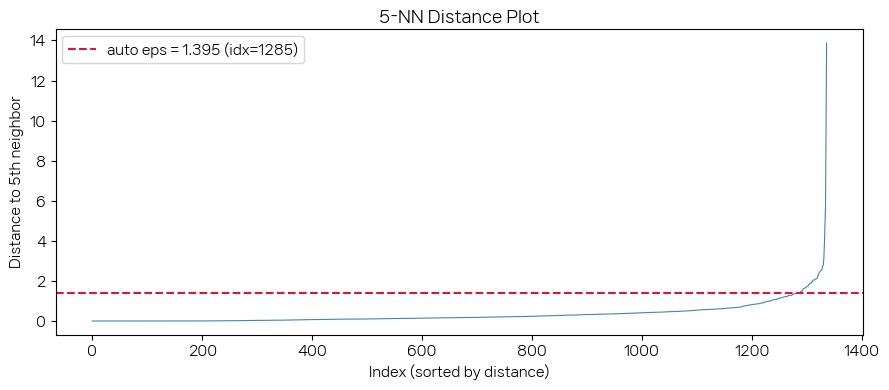

자동 eps = 1.3949

DBSCAN: 2개 클러스터,  noise = 3.7%
                       count
cluster_db (-1=noise)       
-1                        49
 0                       218
 1                      1070

K-Means x DBSCAN 교차표:


DBSCAN label,-1,0,1
KM (parking=1),,,
0,44,218,57
1,5,0,1013


In [5]:
# k-distance plot (k=5)
nbrs  = NearestNeighbors(n_neighbors=5).fit(X)
dists = np.sort(nbrs.kneighbors(X)[0][:, 4])

# 자동 eps: 정규화 후 대각선과의 거리 최대 지점 (knee/elbow)
y_norm = (dists - dists.min()) / (dists.max() - dists.min() + 1e-12)
x_norm = np.linspace(0, 1, len(y_norm))
elbow_idx = int(np.argmax(np.abs(y_norm - x_norm)))
eps_auto  = float(dists[elbow_idx])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists, color='steelblue', linewidth=0.8)
ax.axhline(eps_auto, linestyle='--', color='crimson',
           label=f'auto eps = {eps_auto:.3f} (idx={elbow_idx})')
ax.set_title('5-NN Distance Plot')
ax.set_xlabel('Index (sorted by distance)')
ax.set_ylabel('Distance to 5th neighbor')
ax.legend(); plt.tight_layout()
plt.savefig("figures/02_dbscan_kdist.png", dpi=150, bbox_inches="tight")
plt.show()
print(f'자동 eps = {eps_auto:.4f}')

# DBSCAN
db = DBSCAN(eps=eps_auto, min_samples=10).fit(X)
df_final.loc[idx, 'cluster_db'] = db.labels_

n_clusters_db = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
noise_ratio   = (db.labels_ == -1).mean()
print(f'\nDBSCAN: {n_clusters_db}개 클러스터,  noise = {noise_ratio:.1%}')
db_counts = pd.Series(db.labels_).value_counts().sort_index().rename('count')
db_counts.index.name = 'cluster_db (-1=noise)'
print(db_counts.to_frame().to_string())

# K-Means x DBSCAN 교차표
is_parking_km = (df_final.loc[idx, 'cluster_km'] == parking_cluster_id).astype(int)
ct = pd.crosstab(is_parking_km, db.labels_,
                 rownames=['KM (parking=1)'], colnames=['DBSCAN label'])
print('\nK-Means x DBSCAN 교차표:')
display(ct)


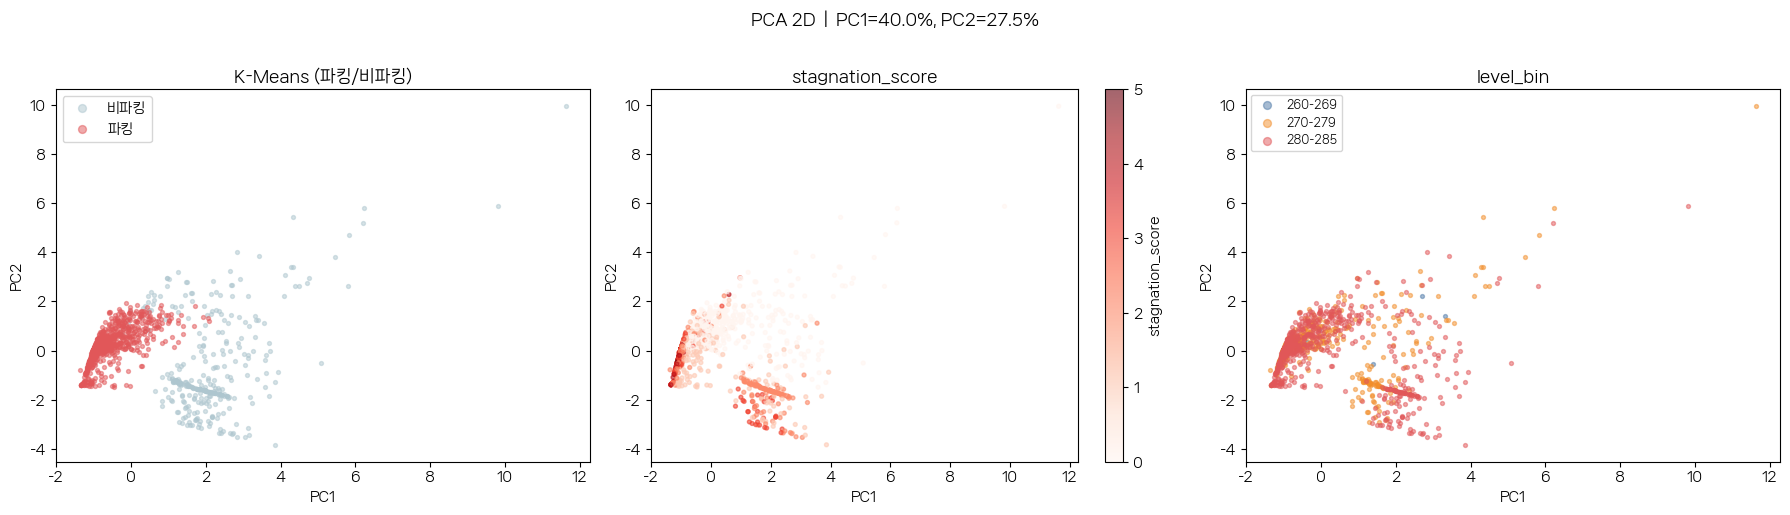

In [6]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=idx)
pca_df = pca_df.join(df_final[['cluster_km', 'stagnation_score', 'level_bin']])
pca_df['is_parking'] = (pca_df['cluster_km'] == parking_cluster_id).astype(int)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: K-Means 파킹/비파킹
for cl, (color, lbl) in enumerate(zip(['#aec6cf', '#e15759'], ['비파킹', '파킹'])):
    mask = pca_df['is_parking'] == cl
    axes[0].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                    s=8, alpha=0.5, color=color, label=lbl)
axes[0].set_title('K-Means (파킹/비파킹)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2)

# Panel 2: stagnation_score
sc = axes[1].scatter(pca_df['PC1'], pca_df['PC2'],
                     c=pca_df['stagnation_score'], cmap='Reds',
                     s=8, alpha=0.6, vmin=0, vmax=5)
plt.colorbar(sc, ax=axes[1], label='stagnation_score')
axes[1].set_title('stagnation_score')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# Panel 3: level_bin
for band in BAND_LABELS:
    mask = pca_df['level_bin'].astype(str) == band
    if mask.sum() > 0:
        axes[2].scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
                        s=8, alpha=0.5,
                        color=BAND_PALETTE.get(band, 'gray'), label=band)
axes[2].set_title('level_bin')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=2, fontsize=8)

ev = pca.explained_variance_ratio_
plt.suptitle(f'PCA 2D  |  PC1={ev[0]:.1%}, PC2={ev[1]:.1%}', y=1.02)
plt.tight_layout()
plt.savefig("figures/03_pca_3panel.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
df_final['is_parking'] = (df_final['cluster_km'] == parking_cluster_id).astype(int)

# 클러스터 레이블 저장 (H2/H3에서 활용)
df_final[['cluster_km', 'is_parking']].to_csv(
    '../data/cluster_labels.csv', index=True, encoding='utf-8-sig'
)

h1_verdict = '분리 가능 (H1 지지)' if best_sil > 0.3 else '약한 분리 (H1 조건부 지지)'
n_parking   = int(df_final['is_parking'].sum())
n_stag5_all = int((df_final['stagnation_score'] == 5).sum())
n_stag5_in  = int(
    (df_final.loc[df_final['is_parking'] == 1, 'stagnation_score'] == 5).sum()
)

print('=' * 55)
print('  H1 판정')
print('=' * 55)
print(f'  Silhouette Score : {best_sil:.4f}')
print(f'  판정             : {h1_verdict}')
print(f'  파킹 클러스터    : {n_parking}명  ({n_parking / len(df_final):.1%})')
print(f'  stagnation=5 집중: {n_stag5_in}/{n_stag5_all}명'
      f'  ({n_stag5_in / max(n_stag5_all, 1) * 100:.1f}%)')
print()
print('  data/cluster_labels.csv 저장 완료')
print('  다음: H2 분포 검정 (Chi-Square by level_band & class_group)')


  H1 판정
  Silhouette Score : 0.5849
  판정             : 분리 가능 (H1 지지)
  파킹 클러스터    : 1018명  (76.1%)
  stagnation=5 집중: 7/7명  (100.0%)

  data/cluster_labels.csv 저장 완료
  다음: H2 분포 검정 (Chi-Square by level_band & class_group)


## 렌 코호트 분석: Feature Set A vs A' 파킹 분류 비교

`created_in_window=1` (2025-06 이후 생성 = 신직업 렌 코호트)에 대해 A와 A'의 파킹 분류율 비교.  
12mo avg_delta 기반(A)이 렌을 '활성'으로 과다 분류하는지(age bias) 정량 검증.


── 코호트별 파킹 분류율 ────────────────────────────────────────────
그룹                                    A (12mo)      A'(r6)      N
--------------------------------------------------------------------
전체                                       76.1%       96.1%   1337
렌 코호트 (created_in_window=1)               0.0%       90.7%    194
기존 캐릭 (created_in_window=0)              89.1%       97.0%   1143


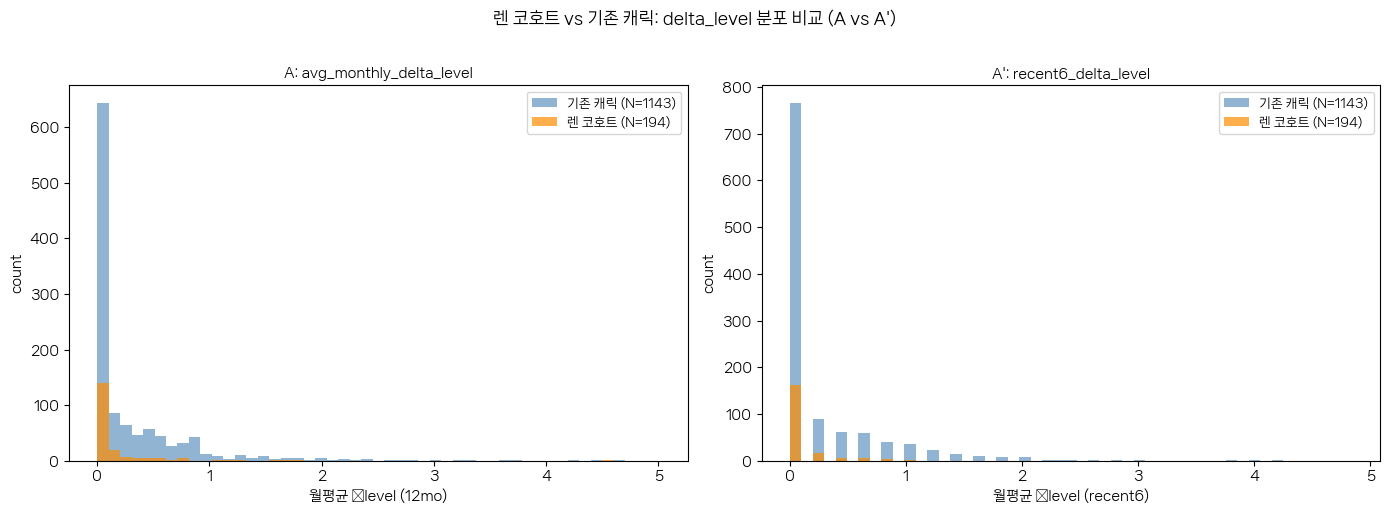


── A vs A' 파킹 레이블 일치 교차표 ────────────────────────────────


is_parking_Ap,0,1,All
is_parking_A,,,
0,44,275,319
1,8,1010,1018
All,52,1285,1337



전체 일치율         : 78.8%
렌 코호트 일치율    : 9.3%

[불일치 해석]
  A에서만 파킹 (age bias 의심)    : 8명 (렌 코호트 중 0명)
  A'에서만 파킹 (최근 정체 신규)   : 275명


In [8]:
if not has_ciw:
    print("created_in_window 컬럼 없음 — 렌 코호트 분석 불가")
elif X_Ap is None:
    print("Feature Set A' 없음 — 비교 불가")
elif 'is_parking' not in df_final.columns:
    print("is_parking 없음 — sec-labels 먼저 실행 필요")
else:
    # 공통 인덱스: A와 A' 모두 유효한 샘플
    common_idx = idx.intersection(idx_Ap)
    sub = df_final.loc[common_idx].copy()

    ren     = sub[sub['created_in_window'].fillna(0) == 1]
    non_ren = sub[sub['created_in_window'].fillna(0) == 0]

    def p_rate(df_, col):
        vals = df_[col].dropna()
        return vals.mean() if len(vals) > 0 else float('nan')

    print("── 코호트별 파킹 분류율 ────────────────────────────────────────────")
    _ap_lbl = "A'(r6)"
    print(f"{'그룹':34s}  {'A (12mo)':>10s}  {_ap_lbl:>10s}  {'N':>5s}")
    print("-" * 68)
    for label, grp in [
        ('전체', sub),
        ('렌 코호트 (created_in_window=1)', ren),
        ('기존 캐릭 (created_in_window=0)', non_ren),
    ]:
        pa  = p_rate(grp, 'is_parking')
        pap = p_rate(grp, 'is_parking_Ap')
        print(f"{label:34s}  {pa:10.1%}  {pap:10.1%}  {len(grp):5d}")

    # ── delta_level 분포 비교 ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (feat, xlabel, title) in zip(axes, [
        ('avg_monthly_delta_level', '월평균 Δlevel (12mo)', 'A: avg_monthly_delta_level'),
        ('recent6_delta_level',     '월평균 Δlevel (recent6)', "A': recent6_delta_level"),
    ]):
        lo = sub[feat].quantile(0.01)
        hi = sub[feat].quantile(0.99)
        bins = np.linspace(lo, hi, 50)
        ax.hist(non_ren[feat].dropna(), bins=bins, alpha=0.6,
                color='steelblue', label=f'기존 캐릭 (N={len(non_ren)})')
        ax.hist(ren[feat].dropna(), bins=bins, alpha=0.7,
                color='darkorange', label=f'렌 코호트 (N={len(ren)})')
        ax.set_title(title, fontsize=10)
        ax.set_xlabel(xlabel); ax.set_ylabel('count')
        ax.legend(fontsize=9)

    plt.suptitle('렌 코호트 vs 기존 캐릭: delta_level 분포 비교 (A vs A\')', y=1.02)
    plt.tight_layout()
    plt.savefig("figures/05_ren_cohort_delta_compare.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── A vs A' 파킹 레이블 교차표 ──────────────────────────────────────────
    ct = pd.crosstab(
        sub['is_parking'].fillna(0).astype(int).rename('is_parking_A'),
        sub['is_parking_Ap'].fillna(0).astype(int).rename("is_parking_Ap"),
        margins=True
    )
    print("\n── A vs A' 파킹 레이블 일치 교차표 ────────────────────────────────")
    display(ct)

    agree = (sub['is_parking'].fillna(0) == sub['is_parking_Ap'].fillna(0)).mean()
    print(f"\n전체 일치율         : {agree:.1%}")

    if len(ren) > 0:
        ren_agree = (ren['is_parking'].fillna(0) == ren['is_parking_Ap'].fillna(0)).mean()
        print(f"렌 코호트 일치율    : {ren_agree:.1%}")

    a_only  = int(((sub['is_parking'].fillna(0)==1) & (sub['is_parking_Ap'].fillna(0)==0)).sum())
    ap_only = int(((sub['is_parking'].fillna(0)==0) & (sub['is_parking_Ap'].fillna(0)==1)).sum())
    ren_a_only = int(((ren['is_parking'].fillna(0)==1) & (ren['is_parking_Ap'].fillna(0)==0)).sum()) if len(ren) > 0 else 0

    print(f"\n[불일치 해석]")
    print(f"  A에서만 파킹 (age bias 의심)    : {a_only}명 (렌 코호트 중 {ren_a_only}명)")
    print(f"  A'에서만 파킹 (최근 정체 신규)   : {ap_only}명")


---

## Feature Set B — 단기 시그널 실험 (recent3/6: 전투력 · 어센틱심볼 · 헥사조각)

**목적:** 12개월 평균 피처 없이 단기(3/6개월) 시그널 3종만으로 파킹 탐지 가능 여부 검증.

| 피처 | 설명 |
|---|---|
| `recent{3,6}_delta_combat_power` | 월평균 전투력 변화량 (winsorize P5–P95) |
| `recent{3,6}_delta_authentic_symbol` | 어센틱 심볼 증감 (≥0 클램핑) |
| `recent{3,6}_delta_hexa_frag` | 헥사 강화 조각 소비 변화량 (`hexa_fragments.csv`) |

> 아케인 심볼·레벨·유니온 제거 — 3개 피처로도 파킹 시그널 포착 여부 확인.


In [9]:
# Feature Set B — 데이터 준비 (hexa_fragments.csv 병합)
hf = pd.read_csv('../data/hexa_fragments.csv', encoding='utf-8-sig',
                 usecols=['ocid', 'avg_monthly_delta_hexa_frag',
                          'recent3_delta_hexa_frag', 'recent6_delta_hexa_frag'])

df_b = df_final.merge(hf, on='ocid', how='left').reset_index(drop=True)

# ── B3 피처 엔지니어링 ──────────────────────────────────────────────────────
df_b['b3_delta_cp'] = np.array(
    winsorize(
        df_b['recent3_delta_combat_power'].fillna(df_b['delta_cp_winsor']),
        limits=[0.05, 0.05]
    )
)
df_b['b3_delta_auth'] = (
    df_b['recent3_delta_authentic_symbol']
    .fillna(df_b['avg_monthly_delta_authentic_symbol'])
    .clip(lower=0)
)
df_b['b3_delta_hfrag'] = (
    df_b['recent3_delta_hexa_frag']
    .fillna(df_b['avg_monthly_delta_hexa_frag'])
    .clip(lower=0)
)

# ── B6 피처 엔지니어링 ──────────────────────────────────────────────────────
df_b['b6_delta_cp'] = np.array(
    winsorize(
        df_b['recent6_delta_combat_power'].fillna(df_b['delta_cp_winsor']),
        limits=[0.05, 0.05]
    )
)
df_b['b6_delta_auth'] = (
    df_b['recent6_delta_authentic_symbol']
    .fillna(df_b['avg_monthly_delta_authentic_symbol'])
    .clip(lower=0)
)
df_b['b6_delta_hfrag'] = (
    df_b['recent6_delta_hexa_frag']
    .fillna(df_b['avg_monthly_delta_hexa_frag'])
    .clip(lower=0)
)

FS_B3 = ['b3_delta_cp', 'b3_delta_auth', 'b3_delta_hfrag']
FS_B6 = ['b6_delta_cp', 'b6_delta_auth', 'b6_delta_hfrag']

df_B3_data = df_b[FS_B3].dropna()
df_B6_data = df_b[FS_B6].dropna()
idx_B3 = df_B3_data.index
idx_B6 = df_B6_data.index

X_B3 = StandardScaler().fit_transform(df_B3_data.values)
X_B6 = StandardScaler().fit_transform(df_B6_data.values)

print(f'Feature Set B3 (recent3) 샘플: {len(X_B3):,}명')
print(f'Feature Set B6 (recent6) 샘플: {len(X_B6):,}명')
print(f'\nhexa_frag NaN 비율:')
print(f'  recent3_delta_hexa_frag : {df_b["recent3_delta_hexa_frag"].isna().mean():.1%}')
print(f'  recent6_delta_hexa_frag : {df_b["recent6_delta_hexa_frag"].isna().mean():.1%}')
print(f'\nb3_delta_hfrag 분포:')
print(df_b['b3_delta_hfrag'].describe().round(1).to_string())


Feature Set B3 (recent3) 샘플: 1,337명
Feature Set B6 (recent6) 샘플: 1,337명

hexa_frag NaN 비율:
  recent3_delta_hexa_frag : 0.0%
  recent6_delta_hexa_frag : 0.0%

b3_delta_hfrag 분포:
count    1337.0
mean       39.0
std       137.9
min         0.0
25%         0.0
50%         0.0
75%         0.0
max      3509.0


B3  elbow k = 8  |  silhouette best k = 2 (0.7829)
B6  elbow k = 8  |  silhouette best k = 2 (0.6978)


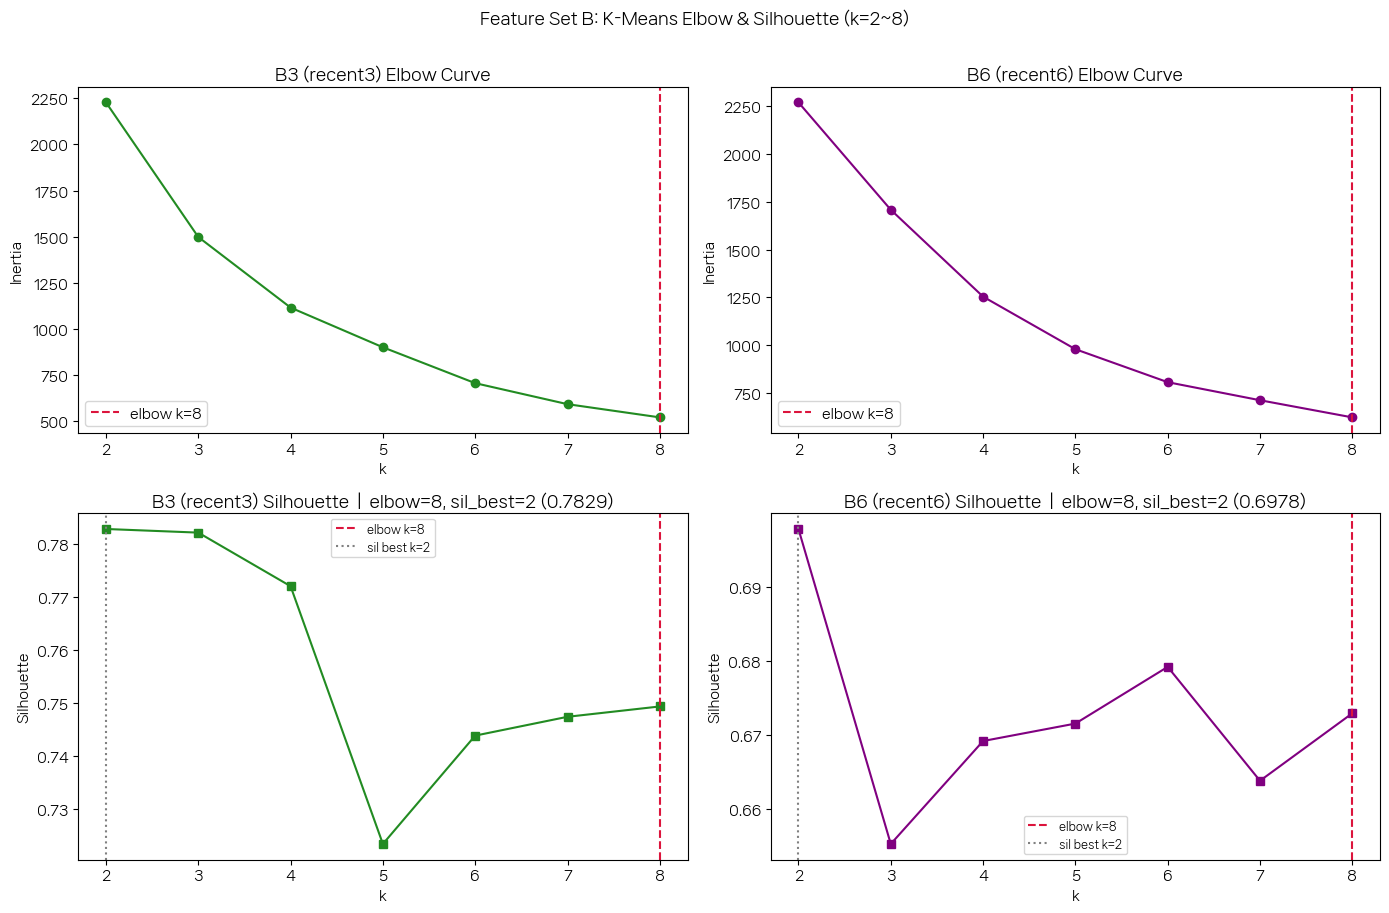


── Silhouette 비교: A / A' / B3 / B6 ──────────────────────────────
   A  (12mo/5f)  A' (r6  /5f)  B3 (r3  /3f)  B6 (r6  /3f)
k                                                        
2        0.5585        0.8106        0.7829        0.6978
3        0.5784        0.6427        0.7822        0.6553
4        0.5849        0.6560        0.7721        0.6692
5        0.5071        0.6463        0.7234        0.6716
6        0.4955        0.6450        0.7438        0.6792
7        0.5026        0.6469        0.7474        0.6639
8        0.4995        0.6552        0.7494        0.6730


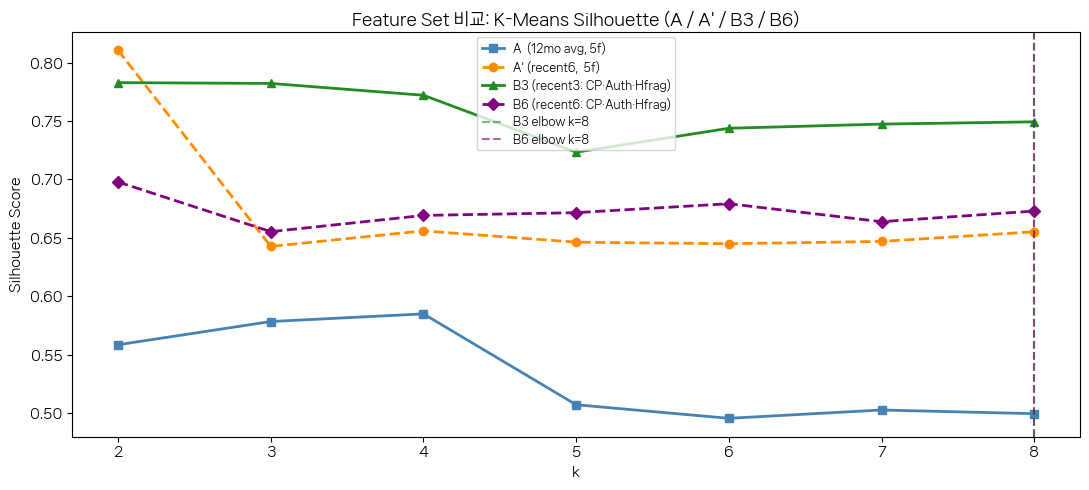

In [10]:
# Feature Set B — Elbow + Silhouette (k=2~8)

ks_b = list(range(2, 9))
sils_B3, sils_B6 = [], []
inertias_B3, inertias_B6 = [], []

for k in ks_b:
    km_b3 = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_B3)
    km_b6 = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_B6)
    inertias_B3.append(km_b3.inertia_)
    inertias_B6.append(km_b6.inertia_)
    sils_B3.append(silhouette_score(X_B3, km_b3.labels_))
    sils_B6.append(silhouette_score(X_B6, km_b6.labels_))

# ── Elbow 자동 탐지 (inertia 정규화 후 대각선 최대 거리) ──────────────────
def find_elbow_k(ks, inertias):
    arr = np.array(inertias, dtype=float)
    y_norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)
    x_norm = np.linspace(0, 1, len(y_norm))
    elbow_idx = int(np.argmax(np.abs(y_norm - x_norm)))
    return ks[elbow_idx]

elbow_k_B3 = find_elbow_k(ks_b, inertias_B3)
elbow_k_B6 = find_elbow_k(ks_b, inertias_B6)
best_k_B3  = ks_b[int(np.argmax(sils_B3))]
best_k_B6  = ks_b[int(np.argmax(sils_B6))]
best_sil_B3 = max(sils_B3)
best_sil_B6 = max(sils_B6)

print(f'B3  elbow k = {elbow_k_B3}  |  silhouette best k = {best_k_B3} ({best_sil_B3:.4f})')
print(f'B6  elbow k = {elbow_k_B6}  |  silhouette best k = {best_k_B6} ({best_sil_B6:.4f})')

# ── Elbow + Silhouette 2×2 ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, inertias, elbow_k, tag, color in [
    (axes[0, 0], inertias_B3, elbow_k_B3, 'B3 (recent3)', 'forestgreen'),
    (axes[0, 1], inertias_B6, elbow_k_B6, 'B6 (recent6)', 'purple'),
]:
    ax.plot(ks_b, inertias, 'o-', color=color)
    ax.axvline(elbow_k, linestyle='--', color='crimson', label=f'elbow k={elbow_k}')
    ax.set_title(f'{tag} Elbow Curve')
    ax.set_xlabel('k'); ax.set_ylabel('Inertia')
    ax.set_xticks(ks_b); ax.legend()

for ax, sils, elbow_k, best_k, best_sil, tag, color in [
    (axes[1, 0], sils_B3, elbow_k_B3, best_k_B3, best_sil_B3, 'B3 (recent3)', 'forestgreen'),
    (axes[1, 1], sils_B6, elbow_k_B6, best_k_B6, best_sil_B6, 'B6 (recent6)', 'purple'),
]:
    ax.plot(ks_b, sils, 's-', color=color)
    ax.axvline(elbow_k, linestyle='--', color='crimson',  label=f'elbow k={elbow_k}')
    ax.axvline(best_k,  linestyle=':',  color='gray',     label=f'sil best k={best_k}')
    ax.set_title(f'{tag} Silhouette  |  elbow={elbow_k}, sil_best={best_k} ({best_sil:.4f})')
    ax.set_xlabel('k'); ax.set_ylabel('Silhouette')
    ax.set_xticks(ks_b); ax.legend(fontsize=8)

plt.suptitle('Feature Set B: K-Means Elbow & Silhouette (k=2~8)', y=1.01)
plt.tight_layout()
plt.savefig('figures/06b_elbow_silhouette_B.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 전체 Silhouette 비교표 ──────────────────────────────────────────────────
_Ap_col = sils_Ap if has_recent6 else [None] * len(ks_b)
comp_b = pd.DataFrame({
    'k'            : ks_b,
    'A  (12mo/5f)' : silhouettes,
    "A' (r6  /5f)" : _Ap_col,
    'B3 (r3  /3f)' : sils_B3,
    'B6 (r6  /3f)' : sils_B6,
}).set_index('k').round(4)
print('\n── Silhouette 비교: A / A\' / B3 / B6 ──────────────────────────────')
print(comp_b.to_string())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(ks_b, silhouettes, 's-',  color='steelblue',  label='A  (12mo avg, 5f)',          linewidth=2)
if has_recent6:
    ax.plot(ks_b, sils_Ap, 'o--', color='darkorange', label="A' (recent6,  5f)",           linewidth=2)
ax.plot(ks_b, sils_B3, '^-',  color='forestgreen',    label='B3 (recent3: CP·Auth·Hfrag)', linewidth=2)
ax.plot(ks_b, sils_B6, 'D--', color='purple',         label='B6 (recent6: CP·Auth·Hfrag)', linewidth=2)
ax.axvline(elbow_k_B3, linestyle='--', color='forestgreen', alpha=0.6, label=f'B3 elbow k={elbow_k_B3}')
ax.axvline(elbow_k_B6, linestyle='--', color='purple',      alpha=0.6, label=f'B6 elbow k={elbow_k_B6}')
ax.set_xlabel('k'); ax.set_ylabel('Silhouette Score')
ax.set_title("Feature Set 비교: K-Means Silhouette (A / A' / B3 / B6)")
ax.set_xticks(ks_b); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('figures/06_silhouette_compare_all.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Feature Set B — 클러스터별 특성 프로파일 (elbow k 우선)

# elbow k 기준으로 B3/B6 선택 (elbow 동점 시 silhouette로 tie-break)
sil_at_elbow_B3 = sils_B3[ks_b.index(elbow_k_B3)]
sil_at_elbow_B6 = sils_B6[ks_b.index(elbow_k_B6)]

if sil_at_elbow_B3 >= sil_at_elbow_B6:
    best_X_B, best_idx_B, best_k_B, best_FS_B, best_sil_B, best_tag_B = \
        X_B3, idx_B3, elbow_k_B3, FS_B3, sil_at_elbow_B3, 'B3 (recent3)'
else:
    best_X_B, best_idx_B, best_k_B, best_FS_B, best_sil_B, best_tag_B = \
        X_B6, idx_B6, elbow_k_B6, FS_B6, sil_at_elbow_B6, 'B6 (recent6)'

print(f'선택: {best_tag_B},  elbow k={best_k_B},  sil={best_sil_B:.4f}')

km_B_best = KMeans(n_clusters=best_k_B, n_init=20, random_state=42)
df_b.loc[best_idx_B, 'cluster_km_B'] = km_B_best.fit_predict(best_X_B)

# 클러스터별 평균 프로파일
diag_cols = ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power',
             'avg_monthly_delta_union_level', 'stagnation_score',
             'arcane_stagnant', 'level']
profile_B = df_b.loc[best_idx_B].groupby('cluster_km_B')[
    best_FS_B + diag_cols
].mean().round(2)
profile_B['n'] = df_b.loc[best_idx_B].groupby('cluster_km_B').size()
profile_B['delta_level≤0.1(%)'] = (
    df_b.loc[best_idx_B].groupby('cluster_km_B')
    .apply(lambda g: (g['avg_monthly_delta_level'] <= 0.1).mean() * 100)
).round(1)
profile_B['stag5(%)'] = (
    df_b.loc[best_idx_B].groupby('cluster_km_B')
    .apply(lambda g: (g['stagnation_score'] == 5).mean() * 100)
).round(1)

print(f'\n=== {best_tag_B} 클러스터 프로파일 (elbow k={best_k_B}, sil={best_sil_B:.4f}) ===\n')
display(profile_B.T)

print('\n레벨 밴드 분포 (행 비율 %):')
lb_dist_B = pd.crosstab(
    df_b.loc[best_idx_B, 'cluster_km_B'],
    df_b.loc[best_idx_B, 'level_bin'],
    normalize='index'
).round(3) * 100
display(lb_dist_B)

if 'class_group' in df_b.columns:
    print('\n계열 분포 (행 비율 %):')
    cg_dist = pd.crosstab(
        df_b.loc[best_idx_B, 'cluster_km_B'],
        df_b.loc[best_idx_B, 'class_group'],
        normalize='index'
    ).round(3) * 100
    display(cg_dist)

선택: B3 (recent3),  elbow k=8,  sil=0.7494

=== B3 (recent3) 클러스터 프로파일 (elbow k=8, sil=0.7494) ===



cluster_km_B,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
b3_delta_cp,-38808.39,1164006.71,10098791.50,11366728.0,-4911252.16,8120022.96,3204107.26,9974555.89
b3_delta_auth,0.02,4.77,0.57,23.0,0.26,9.42,1.07,3.71
b3_delta_hfrag,3.86,115.18,128.57,3509.0,35.69,578.96,116.90,287.88
avg_monthly_delta_level,0.23,1.87,0.46,19.5,0.38,2.48,0.77,0.98
avg_monthly_delta_combat_power,-529072.57,853954.82,3209711.85,75466893.0,-1112784.09,5067613.02,1679389.57,4474173.08
avg_monthly_delta_union_level,28.89,52.22,73.42,46.5,35.08,135.58,70.56,52.36
stagnation_score,2.00,0.26,0.51,0.0,1.20,0.17,0.47,0.02
arcane_stagnant,0.18,0.16,0.02,0.0,0.04,0.00,0.13,0.00
level,276.59,276.10,281.39,285.0,281.29,280.17,279.82,282.71
n,1003.00,31.00,51.00,1.0,107.00,12.00,83.00,49.00



레벨 밴드 분포 (행 비율 %):


level_bin,260-269,270-279,280-285
cluster_km_B,,,
0.0,0.7,58.6,40.7
1.0,3.2,58.1,38.7
2.0,0.0,17.6,82.4
3.0,0.0,0.0,100.0
4.0,0.0,17.8,82.2
5.0,0.0,41.7,58.3
6.0,4.8,26.5,68.7
7.0,0.0,8.2,91.8



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
cluster_km_B,,,,,
0.0,21.0,20.2,18.5,20.4,19.7
1.0,35.5,12.9,9.7,25.8,16.1
2.0,11.8,13.7,15.7,23.5,35.3
3.0,0.0,100.0,0.0,0.0,0.0
4.0,15.9,24.3,25.2,22.4,12.1
5.0,25.0,16.7,50.0,8.3,0.0
6.0,20.5,15.7,27.7,12.0,24.1
7.0,26.5,14.3,26.5,10.2,22.4


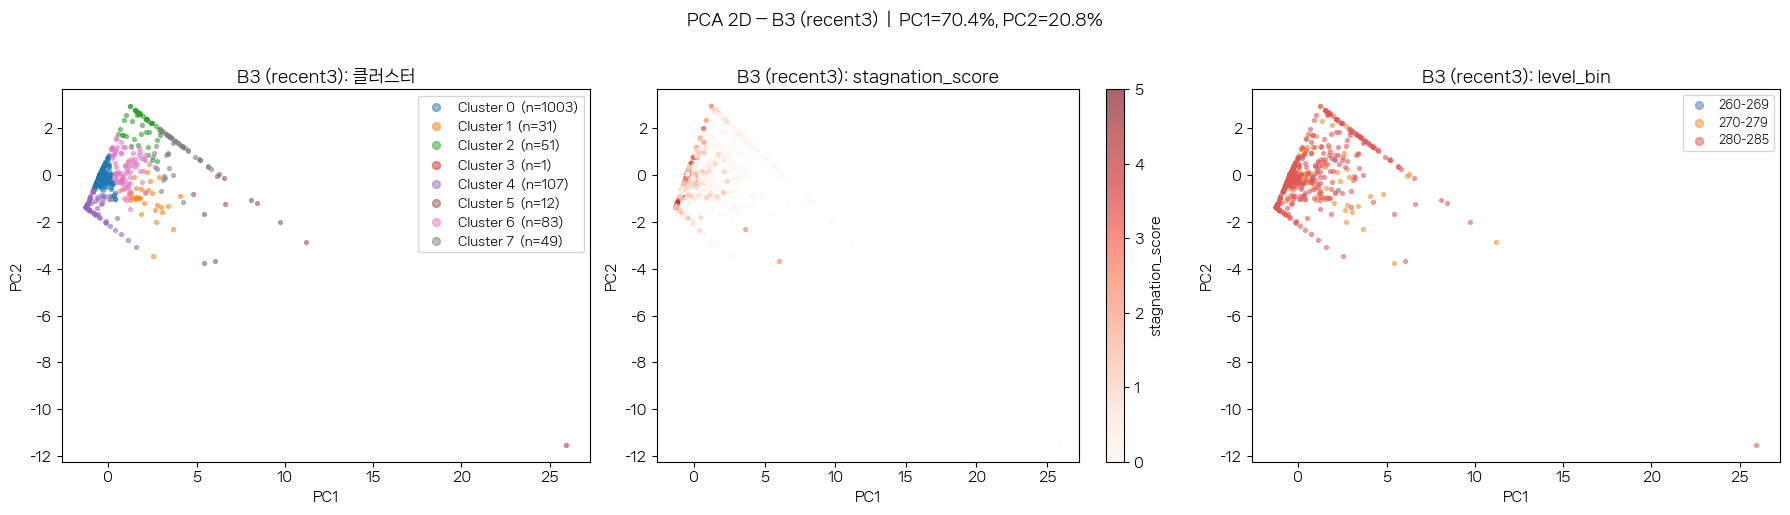

In [12]:
# Feature Set B — PCA 2D 시각화 (클러스터별)

pca_B   = PCA(n_components=2, random_state=42)
X_B_pca = pca_B.fit_transform(best_X_B)

pca_B_df = pd.DataFrame(X_B_pca, columns=['PC1', 'PC2'], index=best_idx_B)
pca_B_df = pca_B_df.join(df_b[['cluster_km_B', 'stagnation_score', 'level_bin']])

palette = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: 클러스터 레이블
for cl in range(best_k_B):
    mask = pca_B_df['cluster_km_B'] == cl
    axes[0].scatter(pca_B_df.loc[mask, 'PC1'], pca_B_df.loc[mask, 'PC2'],
                    s=8, alpha=0.5, color=palette[cl % 10],
                    label=f'Cluster {cl}  (n={mask.sum()})')
axes[0].set_title(f'{best_tag_B}: 클러스터')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=2, fontsize=9)

# Panel 2: stagnation_score
sc = axes[1].scatter(pca_B_df['PC1'], pca_B_df['PC2'],
                     c=pca_B_df['stagnation_score'], cmap='Reds',
                     s=8, alpha=0.6, vmin=0, vmax=5)
plt.colorbar(sc, ax=axes[1], label='stagnation_score')
axes[1].set_title(f'{best_tag_B}: stagnation_score')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

# Panel 3: level_bin
for band in BAND_LABELS:
    mask = pca_B_df['level_bin'].astype(str) == band
    if mask.sum() > 0:
        axes[2].scatter(pca_B_df.loc[mask, 'PC1'], pca_B_df.loc[mask, 'PC2'],
                        s=8, alpha=0.5,
                        color=BAND_PALETTE.get(band, 'gray'), label=band)
axes[2].set_title(f'{best_tag_B}: level_bin')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].legend(markerscale=2, fontsize=8)

ev_B = pca_B.explained_variance_ratio_
plt.suptitle(f'PCA 2D — {best_tag_B}  |  PC1={ev_B[0]:.1%}, PC2={ev_B[1]:.1%}', y=1.02)
plt.tight_layout()
plt.savefig('figures/07_pca_fsB.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Feature Set B — 실험 요약

print('=' * 60)
print(f'  Feature Set B 실험 요약 — {best_tag_B}')
print('=' * 60)
print(f'  피처   : {best_FS_B}')
print(f'  best k : {best_k_B},  Silhouette = {best_sil_B:.4f}')
print()
print('  ── Feature Set 비교 (Silhouette) ──────────────────────')
print(f'  A  (12mo avg, 5 피처) : {best_sil:.4f}  (k={best_k})')
if has_recent6:
    print(f"  A' (recent6,  5 피처) : {best_sil_Ap:.4f}  (k={best_k_Ap})")
print(f'  B3 (recent3,  3 피처) : {best_sil_B3:.4f}  (k={best_k_B3})')
print(f'  B6 (recent6,  3 피처) : {best_sil_B6:.4f}  (k={best_k_B6})')
print()
print('  ── 클러스터별 특성 요약 ────────────────────────────────')
sub_all = df_b.loc[best_idx_B]
for cl_id in sorted(sub_all['cluster_km_B'].dropna().unique()):
    sub = sub_all[sub_all['cluster_km_B'] == cl_id]
    cp_col    = best_FS_B[0]
    auth_col  = best_FS_B[1]
    hfrag_col = best_FS_B[2]
    print(f'  Cluster {int(cl_id)}  (N={len(sub)}명, {len(sub)/len(sub_all):.1%}):')
    print(f'    delta_cp    : {sub[cp_col].mean():>12,.1f}')
    print(f'    delta_auth  : {sub[auth_col].mean():>12.3f}')
    print(f'    delta_hfrag : {sub[hfrag_col].mean():>12.1f}')
    print(f'    stag_score  : {sub["stagnation_score"].mean():>12.2f}')
    print(f'    delta_lv≤0.1: {(sub["avg_monthly_delta_level"] <= 0.1).mean():>11.1%}')

  Feature Set B 실험 요약 — B3 (recent3)
  피처   : ['b3_delta_cp', 'b3_delta_auth', 'b3_delta_hfrag']
  best k : 8,  Silhouette = 0.7494

  ── Feature Set 비교 (Silhouette) ──────────────────────
  A  (12mo avg, 5 피처) : 0.6978  (k=2)
  A' (recent6,  5 피처) : 0.8106  (k=2)
  B3 (recent3,  3 피처) : 0.7829  (k=2)
  B6 (recent6,  3 피처) : 0.6978  (k=2)

  ── 클러스터별 특성 요약 ────────────────────────────────
  Cluster 0  (N=1003명, 75.0%):
    delta_cp    :    -38,808.4
    delta_auth  :        0.023
    delta_hfrag :          3.9
    stag_score  :         2.00
    delta_lv≤0.1:       71.4%
  Cluster 1  (N=31명, 2.3%):
    delta_cp    :  1,164,006.7
    delta_auth  :        4.774
    delta_hfrag :        115.2
    stag_score  :         0.26
    delta_lv≤0.1:        3.2%
  Cluster 2  (N=51명, 3.8%):
    delta_cp    : 10,098,791.5
    delta_auth  :        0.569
    delta_hfrag :        128.6
    stag_score  :         0.51
    delta_lv≤0.1:       19.6%
  Cluster 3  (N=1명, 0.1%):
    delta_cp    : 11,366,728.0
 

---

## Feature Set C — 2피처 실험 (어센틱심볼 + 헥사조각)

전투력 제거. 단기 성장 시그널 2종만으로 파킹 클러스터 분리 가능 여부 확인.

| 피처 | 설명 |
|---|---|
| `recent3/6_delta_authentic_symbol` | 어센틱 심볼 증감 (≥0 클램핑) |
| `recent3/6_delta_hexa_frag` | 헥사 강화 조각 소비량 |

In [14]:
# Feature Set C — 데이터 준비 (2피처: auth + hfrag)

FS_C3 = ['b3_delta_auth', 'b3_delta_hfrag']
FS_C6 = ['b6_delta_auth', 'b6_delta_hfrag']

df_C3_data = df_b[FS_C3].dropna()
df_C6_data = df_b[FS_C6].dropna()
idx_C3 = df_C3_data.index
idx_C6 = df_C6_data.index

X_C3 = StandardScaler().fit_transform(df_C3_data.values)
X_C6 = StandardScaler().fit_transform(df_C6_data.values)

print(f'Feature Set C3 (recent3, 2f) 샘플: {len(X_C3):,}명')
print(f'Feature Set C6 (recent6, 2f) 샘플: {len(X_C6):,}명')
print(f'\nb3_delta_auth  분포:')
print(df_b['b3_delta_auth'].describe().round(3).to_string())
print(f'\nb3_delta_hfrag 분포:')
print(df_b['b3_delta_hfrag'].describe().round(1).to_string())

Feature Set C3 (recent3, 2f) 샘플: 1,337명
Feature Set C6 (recent6, 2f) 샘플: 1,337명

b3_delta_auth  분포:
count    1337.000
mean        0.474
std         1.537
min         0.000
25%         0.000
50%         0.000
75%         0.000
max        23.000

b3_delta_hfrag 분포:
count    1337.0
mean       39.0
std       137.9
min         0.0
25%         0.0
50%         0.0
75%         0.0
max      3509.0


C3  elbow k = 8  |  silhouette best k = 2 (0.8567)
C6  elbow k = 8  |  silhouette best k = 2 (0.8165)


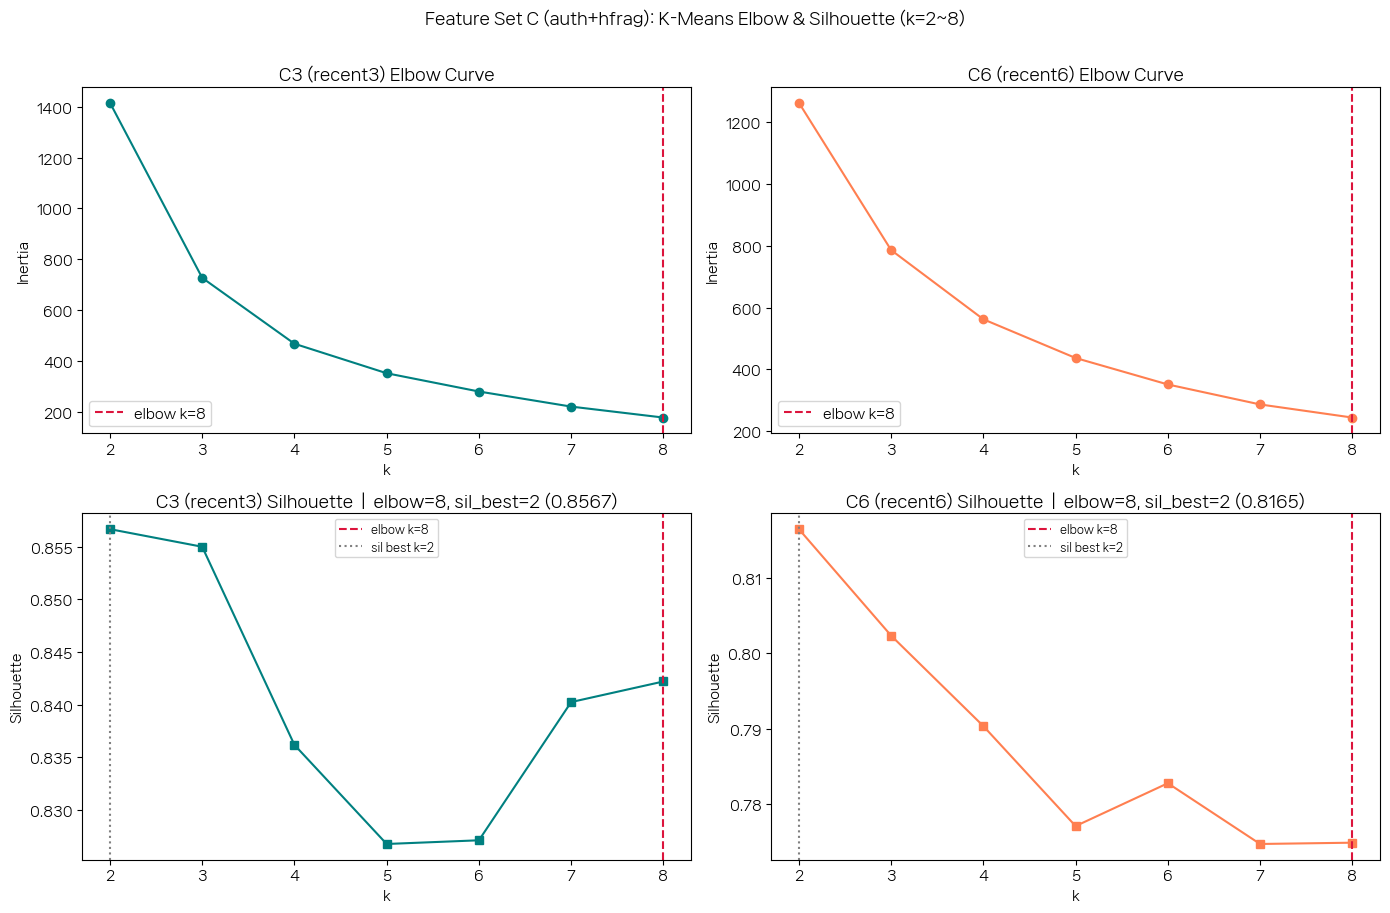


── Silhouette 비교 ─────────────────────────────────────────────────
   A  (12mo/5f)  A' (r6  /5f)  B3 (r3  /3f)  C3 (r3  /2f)  C6 (r6  /2f)
k                                                                      
2        0.5585        0.8106        0.7829        0.8567        0.8165
3        0.5784        0.6427        0.7822        0.8550        0.8023
4        0.5849        0.6560        0.7721        0.8362        0.7904
5        0.5071        0.6463        0.7234        0.8268        0.7771
6        0.4955        0.6450        0.7438        0.8271        0.7828
7        0.5026        0.6469        0.7474        0.8402        0.7747
8        0.4995        0.6552        0.7494        0.8422        0.7749


In [15]:
# Feature Set C — Elbow + Silhouette (k=2~8)

ks_c = list(range(2, 9))
sils_C3, sils_C6 = [], []
inertias_C3, inertias_C6 = [], []

for k in ks_c:
    km_c3 = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_C3)
    km_c6 = KMeans(n_clusters=k, n_init=20, random_state=42).fit(X_C6)
    inertias_C3.append(km_c3.inertia_)
    inertias_C6.append(km_c6.inertia_)
    sils_C3.append(silhouette_score(X_C3, km_c3.labels_))
    sils_C6.append(silhouette_score(X_C6, km_c6.labels_))

elbow_k_C3 = find_elbow_k(ks_c, inertias_C3)
elbow_k_C6 = find_elbow_k(ks_c, inertias_C6)
best_k_C3  = ks_c[int(np.argmax(sils_C3))]
best_k_C6  = ks_c[int(np.argmax(sils_C6))]
best_sil_C3 = max(sils_C3)
best_sil_C6 = max(sils_C6)

print(f'C3  elbow k = {elbow_k_C3}  |  silhouette best k = {best_k_C3} ({best_sil_C3:.4f})')
print(f'C6  elbow k = {elbow_k_C6}  |  silhouette best k = {best_k_C6} ({best_sil_C6:.4f})')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, inertias, elbow_k, tag, color in [
    (axes[0, 0], inertias_C3, elbow_k_C3, 'C3 (recent3)', 'teal'),
    (axes[0, 1], inertias_C6, elbow_k_C6, 'C6 (recent6)', 'coral'),
]:
    ax.plot(ks_c, inertias, 'o-', color=color)
    ax.axvline(elbow_k, linestyle='--', color='crimson', label=f'elbow k={elbow_k}')
    ax.set_title(f'{tag} Elbow Curve')
    ax.set_xlabel('k'); ax.set_ylabel('Inertia')
    ax.set_xticks(ks_c); ax.legend()

for ax, sils, elbow_k, best_k, best_sil, tag, color in [
    (axes[1, 0], sils_C3, elbow_k_C3, best_k_C3, best_sil_C3, 'C3 (recent3)', 'teal'),
    (axes[1, 1], sils_C6, elbow_k_C6, best_k_C6, best_sil_C6, 'C6 (recent6)', 'coral'),
]:
    ax.plot(ks_c, sils, 's-', color=color)
    ax.axvline(elbow_k, linestyle='--', color='crimson', label=f'elbow k={elbow_k}')
    ax.axvline(best_k,  linestyle=':',  color='gray',    label=f'sil best k={best_k}')
    ax.set_title(f'{tag} Silhouette  |  elbow={elbow_k}, sil_best={best_k} ({best_sil:.4f})')
    ax.set_xlabel('k'); ax.set_ylabel('Silhouette')
    ax.set_xticks(ks_c); ax.legend(fontsize=8)

plt.suptitle('Feature Set C (auth+hfrag): K-Means Elbow & Silhouette (k=2~8)', y=1.01)
plt.tight_layout()
plt.savefig('figures/08_elbow_silhouette_C.png', dpi=150, bbox_inches='tight')
plt.show()

# 전체 비교표
comp_c = pd.DataFrame({
    'k'            : ks_c,
    'A  (12mo/5f)' : silhouettes,
    "A' (r6  /5f)" : sils_Ap if has_recent6 else [None]*len(ks_c),
    'B3 (r3  /3f)' : sils_B3,
    'C3 (r3  /2f)' : sils_C3,
    'C6 (r6  /2f)' : sils_C6,
}).set_index('k').round(4)
print('\n── Silhouette 비교 ─────────────────────────────────────────────────')
print(comp_c.to_string())

선택: C3 (recent3),  elbow k=8,  sil=0.8422



=== C3 (recent3) 클러스터 프로파일 (elbow k=8, sil=0.8422) ===



cluster_km_C,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0
b3_delta_auth,0.02,5.16,9.83,23.0,2.88,8.17,2.22,0.33
b3_delta_hfrag,3.00,97.12,1022.50,3509.0,353.49,395.47,93.69,174.94
avg_monthly_delta_level,0.25,1.97,1.52,19.5,0.78,2.53,0.79,0.46
avg_monthly_delta_combat_power,-549293.96,1583280.05,13551752.85,75466893.0,4383973.35,3002935.57,1758872.13,1936276.23
avg_monthly_delta_union_level,30.04,45.05,85.03,46.5,62.33,128.39,75.99,51.01
stagnation_score,1.94,0.21,0.00,0.0,0.05,0.27,0.21,0.56
arcane_stagnant,0.17,0.18,0.00,0.0,0.03,0.00,0.06,0.12
level,276.96,276.75,280.67,285.0,283.31,279.33,280.18,281.43
n,1107.00,28.00,3.00,1.0,39.00,15.00,67.00,77.00
delta_level≤0.1(%),69.00,0.00,0.00,0.0,0.00,13.30,7.50,15.60



레벨 밴드 분포 (행 비율 %):


level_bin,260-269,270-279,280-285
cluster_km_C,,,
0.0,0.6,55.5,43.9
1.0,3.6,50.0,46.4
2.0,0.0,33.3,66.7
3.0,0.0,0.0,100.0
4.0,0.0,2.6,97.4
5.0,0.0,46.7,53.3
6.0,6.0,17.9,76.1
7.0,0.0,20.8,79.2


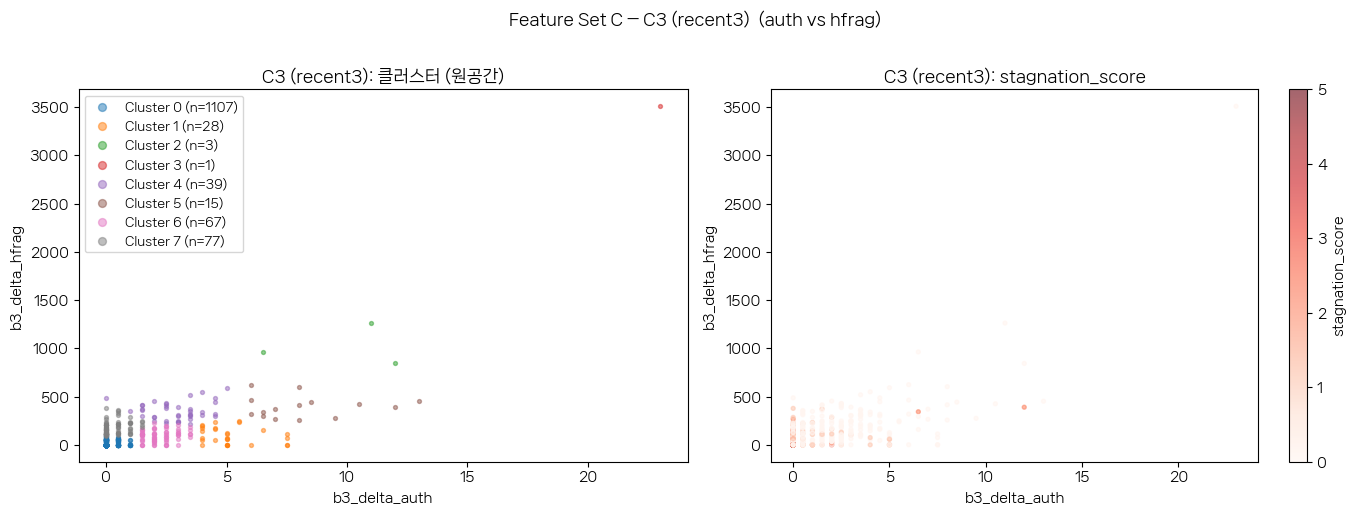

In [16]:
# Feature Set C — 클러스터별 특성 프로파일 (elbow k 기준)

sil_at_elbow_C3 = sils_C3[ks_c.index(elbow_k_C3)]
sil_at_elbow_C6 = sils_C6[ks_c.index(elbow_k_C6)]

if sil_at_elbow_C3 >= sil_at_elbow_C6:
    best_X_C, best_idx_C, best_k_C, best_FS_C, best_sil_C, best_tag_C = \
        X_C3, idx_C3, elbow_k_C3, FS_C3, sil_at_elbow_C3, 'C3 (recent3)'
else:
    best_X_C, best_idx_C, best_k_C, best_FS_C, best_sil_C, best_tag_C = \
        X_C6, idx_C6, elbow_k_C6, FS_C6, sil_at_elbow_C6, 'C6 (recent6)'

print(f'선택: {best_tag_C},  elbow k={best_k_C},  sil={best_sil_C:.4f}')

km_C_best = KMeans(n_clusters=best_k_C, n_init=20, random_state=42)
df_b.loc[best_idx_C, 'cluster_km_C'] = km_C_best.fit_predict(best_X_C)

diag_cols = ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power',
             'avg_monthly_delta_union_level', 'stagnation_score',
             'arcane_stagnant', 'level']
profile_C = df_b.loc[best_idx_C].groupby('cluster_km_C')[
    best_FS_C + diag_cols
].mean().round(2)
profile_C['n'] = df_b.loc[best_idx_C].groupby('cluster_km_C').size()
profile_C['delta_level≤0.1(%)'] = (
    df_b.loc[best_idx_C].groupby('cluster_km_C')
    .apply(lambda g: (g['avg_monthly_delta_level'] <= 0.1).mean() * 100)
).round(1)
profile_C['stag5(%)'] = (
    df_b.loc[best_idx_C].groupby('cluster_km_C')
    .apply(lambda g: (g['stagnation_score'] == 5).mean() * 100)
).round(1)

print(f'\n=== {best_tag_C} 클러스터 프로파일 (elbow k={best_k_C}, sil={best_sil_C:.4f}) ===\n')
display(profile_C.T)

print('\n레벨 밴드 분포 (행 비율 %):')
display(pd.crosstab(
    df_b.loc[best_idx_C, 'cluster_km_C'],
    df_b.loc[best_idx_C, 'level_bin'],
    normalize='index'
).round(3) * 100)

# ── 2D scatter (2피처라 PCA 불필요 — 원공간 직접 시각화) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = plt.cm.tab10.colors
for cl in range(best_k_C):
    mask = df_b.loc[best_idx_C, 'cluster_km_C'] == cl
    x = df_b.loc[best_idx_C[mask], best_FS_C[0]]
    y = df_b.loc[best_idx_C[mask], best_FS_C[1]]
    axes[0].scatter(x, y, s=8, alpha=0.5, color=palette[cl % 10],
                    label=f'Cluster {cl} (n={mask.sum()})')
axes[0].set_xlabel(best_FS_C[0]); axes[0].set_ylabel(best_FS_C[1])
axes[0].set_title(f'{best_tag_C}: 클러스터 (원공간)')
axes[0].legend(markerscale=2, fontsize=9)

sc = axes[1].scatter(
    df_b.loc[best_idx_C, best_FS_C[0]],
    df_b.loc[best_idx_C, best_FS_C[1]],
    c=df_b.loc[best_idx_C, 'stagnation_score'],
    cmap='Reds', s=8, alpha=0.6, vmin=0, vmax=5
)
plt.colorbar(sc, ax=axes[1], label='stagnation_score')
axes[1].set_xlabel(best_FS_C[0]); axes[1].set_ylabel(best_FS_C[1])
axes[1].set_title(f'{best_tag_C}: stagnation_score')

plt.suptitle(f'Feature Set C — {best_tag_C}  (auth vs hfrag)', y=1.02)
plt.tight_layout()
plt.savefig('figures/09_scatter_C.png', dpi=150, bbox_inches='tight')
plt.show()

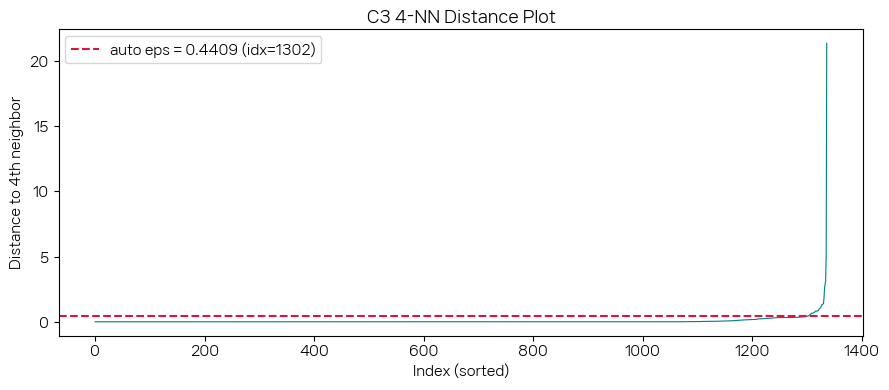

auto eps = 0.4409,  min_samples = 4
DBSCAN: 2개 클러스터,  noise = 2.1%  (28명)

                         count
cluster_db_C (-1=noise)       
-1                          28
 0                        1304
 1                           5


In [17]:
# Feature Set C — DBSCAN (k-distance → auto eps)
# 2차원 피처 → min_samples = 2*dim = 4

MIN_SAMPLES = 4

nbrs_C = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_C3)
dists_C = np.sort(nbrs_C.kneighbors(X_C3)[0][:, MIN_SAMPLES - 1])

y_norm_C = (dists_C - dists_C.min()) / (dists_C.max() - dists_C.min() + 1e-12)
x_norm_C = np.linspace(0, 1, len(y_norm_C))
elbow_idx_C = int(np.argmax(np.abs(y_norm_C - x_norm_C)))
eps_auto_C  = float(dists_C[elbow_idx_C])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(dists_C, color='teal', linewidth=0.8)
ax.axhline(eps_auto_C, linestyle='--', color='crimson',
           label=f'auto eps = {eps_auto_C:.4f} (idx={elbow_idx_C})')
ax.set_title(f'C3 {MIN_SAMPLES}-NN Distance Plot')
ax.set_xlabel('Index (sorted)'); ax.set_ylabel(f'Distance to {MIN_SAMPLES}th neighbor')
ax.legend(); plt.tight_layout()
plt.savefig('figures/10_dbscan_kdist_C.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'auto eps = {eps_auto_C:.4f},  min_samples = {MIN_SAMPLES}')

# ── DBSCAN ──────────────────────────────────────────────────────────────────
db_C = DBSCAN(eps=eps_auto_C, min_samples=MIN_SAMPLES).fit(X_C3)
df_b.loc[idx_C3, 'cluster_db_C'] = db_C.labels_

n_clusters_C = len(set(db_C.labels_)) - (1 if -1 in db_C.labels_ else 0)
noise_ratio_C = (db_C.labels_ == -1).mean()
print(f'DBSCAN: {n_clusters_C}개 클러스터,  noise = {noise_ratio_C:.1%}  ({int((db_C.labels_==-1).sum())}명)')
print()
counts_C = pd.Series(db_C.labels_).value_counts().sort_index().rename('count')
counts_C.index.name = 'cluster_db_C (-1=noise)'
print(counts_C.to_frame().to_string())

=== DBSCAN 클러스터 프로파일 (C3: auth+hfrag) ===
(-1 = noise)



cluster_db_C,-1.0,0.0,1.0
b3_delta_auth,7.75,0.29,6.60
b3_delta_hfrag,529.68,27.35,317.70
avg_monthly_delta_level,3.24,0.32,2.33
avg_monthly_delta_combat_power,6653864.11,-131524.23,4108336.80
stagnation_score,0.07,1.69,0.40
arcane_stagnant,0.00,0.16,0.00
level,279.21,277.56,278.00
n,28.00,1304.00,5.00
delta_level≤0.1(%),3.60,59.90,20.00
stag5(%),0.00,0.50,0.00


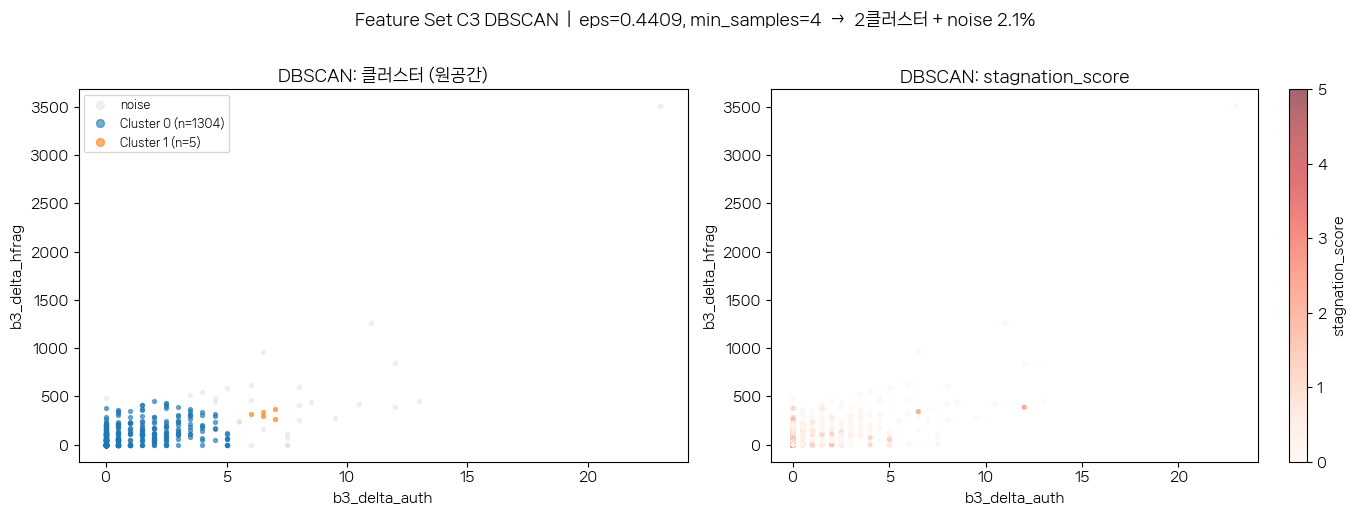

In [18]:
# Feature Set C — DBSCAN 클러스터 프로파일 + 시각화

diag_cols = ['avg_monthly_delta_level', 'avg_monthly_delta_combat_power',
             'stagnation_score', 'arcane_stagnant', 'level']

db_sub = df_b.loc[idx_C3].copy()
profile_db_C = db_sub.groupby('cluster_db_C')[
    FS_C3 + diag_cols
].mean().round(2)
profile_db_C['n'] = db_sub.groupby('cluster_db_C').size()
profile_db_C['delta_level≤0.1(%)'] = (
    db_sub.groupby('cluster_db_C')
    .apply(lambda g: (g['avg_monthly_delta_level'] <= 0.1).mean() * 100)
).round(1)
profile_db_C['stag5(%)'] = (
    db_sub.groupby('cluster_db_C')
    .apply(lambda g: (g['stagnation_score'] == 5).mean() * 100)
).round(1)

print('=== DBSCAN 클러스터 프로파일 (C3: auth+hfrag) ===')
print('(-1 = noise)\n')
display(profile_db_C.T)

# ── 시각화 ───────────────────────────────────────────────────────────────────
labels_db_C = db_sub['cluster_db_C'].values
unique_labels = sorted(set(labels_db_C))
palette = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lbl in unique_labels:
    mask = labels_db_C == lbl
    color = 'lightgray' if lbl == -1 else palette[int(lbl) % 10]
    name  = 'noise' if lbl == -1 else f'Cluster {int(lbl)} (n={mask.sum()})'
    alpha = 0.3 if lbl == -1 else 0.6
    axes[0].scatter(
        db_sub.loc[idx_C3[mask], FS_C3[0]],
        db_sub.loc[idx_C3[mask], FS_C3[1]],
        s=8, alpha=alpha, color=color, label=name
    )
axes[0].set_xlabel(FS_C3[0]); axes[0].set_ylabel(FS_C3[1])
axes[0].set_title('DBSCAN: 클러스터 (원공간)')
axes[0].legend(markerscale=2, fontsize=8)

sc = axes[1].scatter(
    db_sub[FS_C3[0]], db_sub[FS_C3[1]],
    c=db_sub['stagnation_score'], cmap='Reds',
    s=8, alpha=0.6, vmin=0, vmax=5
)
plt.colorbar(sc, ax=axes[1], label='stagnation_score')
axes[1].set_xlabel(FS_C3[0]); axes[1].set_ylabel(FS_C3[1])
axes[1].set_title('DBSCAN: stagnation_score')

plt.suptitle(f'Feature Set C3 DBSCAN  |  eps={eps_auto_C:.4f}, min_samples={MIN_SAMPLES}  →  {n_clusters_C}클러스터 + noise {noise_ratio_C:.1%}', y=1.02)
plt.tight_layout()
plt.savefig('figures/11_dbscan_C.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Sub-Clustering: Cluster 0 세분화 실험

C3 K-Means Cluster 0 (정체 그룹, ~83%)를 추가 피처로 세분화.  
**Step 1**: Cluster 0 내부 피처 variance 탐색 → 유효 피처 식별  
**Step 2**: 후보 피처셋 조합 grid search → silhouette 최고 조합 선택  
**Step 3**: 최적 조합으로 최종 클러스터 프로파일

In [19]:
# Step 1: Cluster 0 내부 피처 variance 탐색

sub0 = df_b.loc[idx_C3][df_b.loc[idx_C3, 'cluster_km_C'] == 0.0].copy()
print(f'Cluster 0 크기: {len(sub0)}명')

# 후보 피처 풀 (클러스터링에 쓸 수 있는 연속형 컬럼)
candidate_pool = [
    'avg_monthly_delta_level',
    'recent3_delta_level', 'recent6_delta_level',
    'avg_monthly_delta_arcane_symbol', 'recent3_delta_arcane_symbol',
    'avg_monthly_delta_union_level',   'recent3_delta_union_level',
    'avg_monthly_delta_combat_power',  'recent3_delta_combat_power',
    'avg_monthly_delta_authentic_symbol', 'recent3_delta_authentic_symbol',
    'avg_monthly_delta_hexa',          'recent3_delta_hexa_frag',
    'hexa_level_sum', 'arcane_symbol_score', 'authentic_symbol_score',
    'access_ratio', 'access_active_months', 'access_recent',
]
candidate_pool = [c for c in candidate_pool if c in sub0.columns]

stats = sub0[candidate_pool].agg(['mean', 'std', 'min', 'max']).T
stats['cv'] = (stats['std'] / (stats['mean'].abs() + 1e-9)).round(3)  # coefficient of variation
stats['nonzero%'] = (sub0[candidate_pool] != 0).mean().round(3) * 100
stats = stats.sort_values('cv', ascending=False)

print('\n── Cluster 0 내부 피처 분산 (CV 내림차순) ──────────────────────────')
display(stats.round(3))

# CV > 0.5 이고 nonzero% > 10% 인 피처만 유효 후보
valid = stats[(stats['cv'] > 0.5) & (stats['nonzero%'] > 10)].index.tolist()
print(f'\n유효 후보 피처 ({len(valid)}개): {valid}')

Cluster 0 크기: 1107명

── Cluster 0 내부 피처 분산 (CV 내림차순) ──────────────────────────


,mean,std,min,max,cv,nonzero%
recent3_delta_authentic_symbol,-0.001,0.636,-1.900000e+01,1.000000e+00,469.565,4.3
recent3_delta_arcane_symbol,-0.086,2.565,-6.000000e+01,6.500000e+00,29.889,1.3
recent3_delta_combat_power,-952783.302,7596044.922,-1.371733e+08,2.115349e+07,7.972,30.5
avg_monthly_delta_combat_power,-549293.959,2894461.152,-2.346679e+07,1.918883e+07,5.269,76.8
recent3_delta_hexa_frag,3.003,12.696,0.000000e+00,8.950000e+01,4.228,6.1
avg_monthly_delta_level,0.253,0.978,0.000000e+00,2.436400e+01,3.863,42.4
recent3_delta_union_level,14.167,51.997,-5.000000e-01,6.505000e+02,3.670,20.8
recent3_delta_level,0.096,0.347,0.000000e+00,4.500000e+00,3.619,10.1
recent6_delta_level,0.102,0.351,0.000000e+00,6.600000e+00,3.447,18.2
avg_monthly_delta_union_level,30.041,79.313,-1.631820e+02,7.376360e+02,2.640,62.4



유효 후보 피처 (14개): ['recent3_delta_combat_power', 'avg_monthly_delta_combat_power', 'avg_monthly_delta_level', 'recent3_delta_union_level', 'recent3_delta_level', 'recent6_delta_level', 'avg_monthly_delta_union_level', 'access_recent', 'avg_monthly_delta_arcane_symbol', 'avg_monthly_delta_hexa', 'avg_monthly_delta_authentic_symbol', 'access_active_months', 'access_ratio', 'hexa_level_sum']


In [20]:
# Step 2: grid search — QuantileTransformer (비선형 스케일 보정)
from itertools import combinations
from sklearn.preprocessing import QuantileTransformer

FOCUS = [
    "avg_monthly_delta_combat_power",
    "recent3_delta_combat_power",
    "avg_monthly_delta_union_level",
    "recent3_delta_union_level",
    "access_ratio",
    "access_active_months",
    "access_recent",
    "hexa_level_sum",
    "avg_monthly_delta_hexa",
    "avg_monthly_delta_authentic_symbol",
]
FOCUS = [c for c in FOCUS if c in sub0.columns]
print("후보 피처:", FOCUS)

def make_scaler(n):
    return QuantileTransformer(n_quantiles=min(n, 1000),
                               output_distribution="normal",
                               random_state=42)

ks_sub = list(range(2, 6))
MIN_N = 20
results = []

for n_feats in [2, 3]:
    for fs in combinations(FOCUS, n_feats):
        fs = list(fs)
        data = sub0[fs].dropna()
        if len(data) < 50:
            continue
        X_sub = make_scaler(len(data)).fit_transform(data.values)
        for k in ks_sub:
            try:
                lbl = KMeans(n_clusters=k, n_init=10, random_state=42).fit_predict(X_sub)
                counts = pd.Series(lbl).value_counts()
                if counts.min() < MIN_N:
                    continue
                sil = silhouette_score(X_sub, lbl)
                results.append({"features": tuple(fs), "k": k, "n": len(data),
                                 "silhouette": round(sil, 4), "min_n": int(counts.min())})
            except Exception:
                pass

res_df = pd.DataFrame(results).sort_values("silhouette", ascending=False).reset_index(drop=True)
print("유효 조합 (min_cluster>=%d): %d개" % (MIN_N, len(results)))
for _, row in res_df.head(15).iterrows():
    print("  sil=%.4f  k=%d  min_n=%4d  %s" % (row["silhouette"], row["k"], row["min_n"], list(row["features"])))
best_row = res_df.iloc[0]
print("best:", list(best_row["features"]), "k=%d sil=%.4f min_n=%d" % (best_row["k"], best_row["silhouette"], best_row["min_n"]))


후보 피처: ['avg_monthly_delta_combat_power', 'recent3_delta_combat_power', 'avg_monthly_delta_union_level', 'recent3_delta_union_level', 'access_ratio', 'access_active_months', 'access_recent', 'hexa_level_sum', 'avg_monthly_delta_hexa', 'avg_monthly_delta_authentic_symbol']


유효 조합 (min_cluster>=20): 640개
  sil=0.9631  k=2  min_n= 164  ['recent3_delta_union_level', 'access_recent']
  sil=0.9562  k=3  min_n=  96  ['recent3_delta_union_level', 'access_recent']
  sil=0.9500  k=4  min_n=  53  ['access_recent', 'avg_monthly_delta_authentic_symbol']
  sil=0.9318  k=4  min_n=  31  ['recent3_delta_union_level', 'access_recent']
  sil=0.9313  k=2  min_n= 164  ['recent3_delta_combat_power', 'access_recent']
  sil=0.9278  k=3  min_n=  73  ['recent3_delta_combat_power', 'access_recent']
  sil=0.9241  k=4  min_n=  49  ['access_ratio', 'access_recent']
  sil=0.9236  k=4  min_n=  44  ['access_active_months', 'access_recent']
  sil=0.9193  k=3  min_n= 164  ['access_recent', 'avg_monthly_delta_authentic_symbol']
  sil=0.9188  k=5  min_n=  55  ['recent3_delta_combat_power', 'access_recent']
  sil=0.9157  k=4  min_n=  49  ['access_ratio', 'access_active_months', 'access_recent']
  sil=0.9142  k=2  min_n= 164  ['recent3_delta_combat_power', 'recent3_delta_union_level', 'access

=== Sub-Clustering (QuantileTransformer) ===
피처: ['recent3_delta_union_level', 'access_recent']
k=2  Silhouette=0.9631



subcluster,0.0,1.0
recent3_delta_union_level,5.97,61.28
access_recent,0.00,1.00
avg_monthly_delta_level,0.24,0.35
delta_cp_winsor,-383076.66,-66487.89
avg_monthly_delta_union_level,27.90,42.36
stagnation_score,2.08,1.10
arcane_stagnant,0.17,0.16
level,276.63,278.84
n,943.00,164.00
delta_level_le_0.1_pct,75.90,29.30



레벨 밴드 분포 (행 비율 %):


level_bin,260-269,270-279,280-285
subcluster,,,
0.0,0.4,58.5,41.0
1.0,1.8,37.8,60.4



계열 분포 (행 비율 %):


class_group,궁수,도적,마법사,전사,해적
subcluster,,,,,
0.0,20.1,20.5,18.0,21.3,20.0
1.0,18.9,18.9,25.0,18.3,18.9


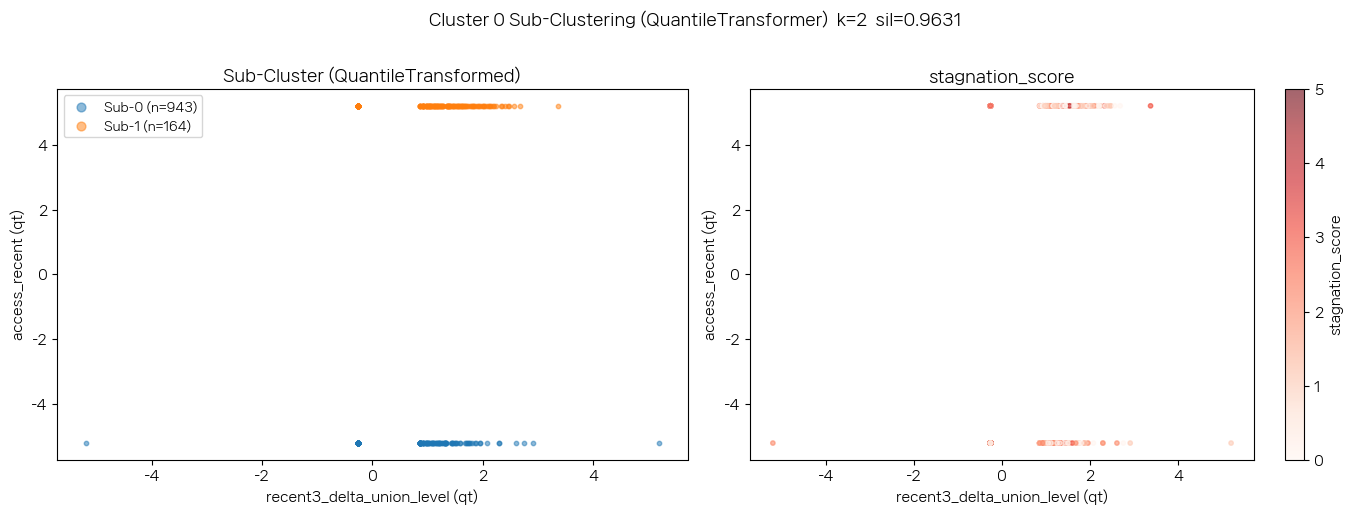

In [21]:
# Step 3: 최적 피처셋으로 Sub-Clustering (QuantileTransformer)
from sklearn.preprocessing import QuantileTransformer

best_fs    = list(best_row["features"])
best_k_sub = int(best_row["k"])

data_sub   = sub0[best_fs].dropna()
idx_sub    = data_sub.index
qt         = QuantileTransformer(n_quantiles=min(len(data_sub), 1000),
                                  output_distribution="normal", random_state=42)
X_sub_best = qt.fit_transform(data_sub.values)

km_sub = KMeans(n_clusters=best_k_sub, n_init=20, random_state=42)
sub0.loc[idx_sub, "subcluster"] = km_sub.fit_predict(X_sub_best)

diag_cols2 = ["avg_monthly_delta_level", "delta_cp_winsor",
              "avg_monthly_delta_union_level", "stagnation_score",
              "arcane_stagnant", "level"]
diag_cols2 = [c for c in diag_cols2 if c in sub0.columns]

prof_sub = sub0.loc[idx_sub].groupby("subcluster")[
    best_fs + diag_cols2
].mean().round(2)
prof_sub["n"] = sub0.loc[idx_sub].groupby("subcluster").size()
prof_sub["delta_level_le_0.1_pct"] = (
    sub0.loc[idx_sub].groupby("subcluster")
    .apply(lambda g: (g["avg_monthly_delta_level"] <= 0.1).mean() * 100)
).round(1)
prof_sub["stag5_pct"] = (
    sub0.loc[idx_sub].groupby("subcluster")
    .apply(lambda g: (g["stagnation_score"] == 5).mean() * 100)
).round(1)

sil_sub = silhouette_score(X_sub_best, km_sub.labels_)
print("=== Sub-Clustering (QuantileTransformer) ===")
print("피처:", best_fs)
print("k=%d  Silhouette=%.4f" % (best_k_sub, sil_sub))
print()
display(prof_sub.T)

print()
print("레벨 밴드 분포 (행 비율 %):")
display(pd.crosstab(
    sub0.loc[idx_sub, "subcluster"],
    sub0.loc[idx_sub, "level_bin"],
    normalize="index"
).round(3) * 100)

if "class_group" in sub0.columns:
    print()
    print("계열 분포 (행 비율 %):")
    display(pd.crosstab(
        sub0.loc[idx_sub, "subcluster"],
        sub0.loc[idx_sub, "class_group"],
        normalize="index"
    ).round(3) * 100)

if len(best_fs) == 2:
    coords = X_sub_best
    xlabel = best_fs[0] + " (qt)"
    ylabel = best_fs[1] + " (qt)"
    title_suffix = "QuantileTransformed"
else:
    pca_sub = PCA(n_components=2, random_state=42)
    coords = pca_sub.fit_transform(X_sub_best)
    ev = pca_sub.explained_variance_ratio_
    xlabel = "PC1 (%.1f%%)" % (ev[0] * 100)
    ylabel = "PC2 (%.1f%%)" % (ev[1] * 100)
    title_suffix = "PCA 2D (%.1f%%)" % ((ev[0] + ev[1]) * 100)

palette = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl in range(best_k_sub):
    mask = sub0.loc[idx_sub, "subcluster"] == cl
    axes[0].scatter(coords[mask, 0], coords[mask, 1],
                    s=10, alpha=0.5, color=palette[cl % 10],
                    label="Sub-%d (n=%d)" % (cl, mask.sum()))
axes[0].set_xlabel(xlabel)
axes[0].set_ylabel(ylabel)
axes[0].set_title("Sub-Cluster (%s)" % title_suffix)
axes[0].legend(markerscale=2, fontsize=9)

sc2 = axes[1].scatter(coords[:, 0], coords[:, 1],
                      c=sub0.loc[idx_sub, "stagnation_score"],
                      cmap="Reds", s=10, alpha=0.6, vmin=0, vmax=5)
plt.colorbar(sc2, ax=axes[1], label="stagnation_score")
axes[1].set_xlabel(xlabel)
axes[1].set_ylabel(ylabel)
axes[1].set_title("stagnation_score")

plt.suptitle("Cluster 0 Sub-Clustering (QuantileTransformer)  k=%d  sil=%.4f" % (best_k_sub, sil_sub), y=1.02)
plt.tight_layout()
plt.savefig("figures/12_subclustering.png", dpi=150, bbox_inches="tight")
plt.show()
